# Tokenization Papers

In [1]:
import paper_dataset
import pandas as pd
import importlib
import re
import matplotlib.pyplot as plt
importlib.reload(paper_dataset)

<module 'paper_dataset' from '/lnet/work/people/vico/TokSurvey/paper_dataset.py'>

In [2]:
import seaborn as sns
sns.set_theme(style="darkgrid")
sns.set_context("talk",  font_scale=1.5, rc={"lines.linewidth": 2.5})
sns.set_palette("colorblind")

In [ ]:
df = paper_dataset.load()

## Samples and RE 

In [ ]:
samples = paper_dataset.sample(df, 5)
for s in samples.iloc:
    paper_dataset.print_sample(s)

Title: The Geometry of Numerical Reasoning: Language Models Compare Numeric Properties in Linear Subspaces
Author(s): El-Shangiti, Ahmed Oumar and Hiraoka, Tatsuya and AlQuabeh, Hilal and Heinzerling, Benjamin and Inui, Kentaro
Year: 2025
Venue: None (ACL)
Volume: Proceedings of the 2025 Conference of the Nations of the Americas Chapter of the Association for Computational Linguistics: Human Language Technologies (Volume 2: Short Papers)
--------------------------------------------------------------------------------
Abstract:
   This paper investigates whether large language models (LLMs) utilize
   numerical attributes encoded in a low-dimensional subspace of
   theembedding space when answering questions involving numeric
   comparisons, e.g., Was Cristiano born before Messi? We first
   identified,using partial least squares regression, these subspaces,
   which effectively encode the numerical attributes associated with the
   entities in comparison prompts. Further, we demonstrat

In [3]:
recent = df[df['year'] >= 2016]
keywords = re.compile(r"token|sub-?word|segment")
tokenization = recent[recent["abstract"].apply(lambda x: x is not None and re.search(keywords, x.lower()) is not None)]

print(f"Number of papers in the dataset: {len(df)}")
print(f"Number of papers since 2016: {len(recent)}")
print(f"Number of papers on tokenization since 2016: {len(tokenization)}")

Number of papers in the dataset: 149355
Number of papers since 2016: 101891
Number of papers on tokenization since 2016: 8266


In [ ]:
samples = paper_dataset.sample(tokenization, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

Title: Spike-driven Transformer V2: Meta Spiking Neural Network Architecture Inspiring the Design of Next-generation Neuromorphic Chips
Author(s): Man Yao and JiaKui Hu and Tianxiang Hu and Yifan Xu and Zhaokun Zhou and Yonghong Tian and Bo XU and Guoqi Li
Year: 2024
Venue: ICLR 2024 poster (ICLR)
Volume: The Twelfth International Conference on Learning Representations
--------------------------------------------------------------------------------
Abstract:
   Neuromorphic computing, which exploits Spiking Neural Networks (SNNs) on
   neuromorphic chips, is a promising energy-efficient alternative to
   traditional AI. CNN-based SNNs are the current mainstream of
   neuromorphic computing. By contrast, no neuromorphic chips are designed
   especially for Transformer-based SNNs, which have just emerged, and
   their performance is only on par with CNN-based SNNs, offering no
   distinct advantage. In this work, we propose a general Transformer-based
   SNN architecture, termed as ``Met

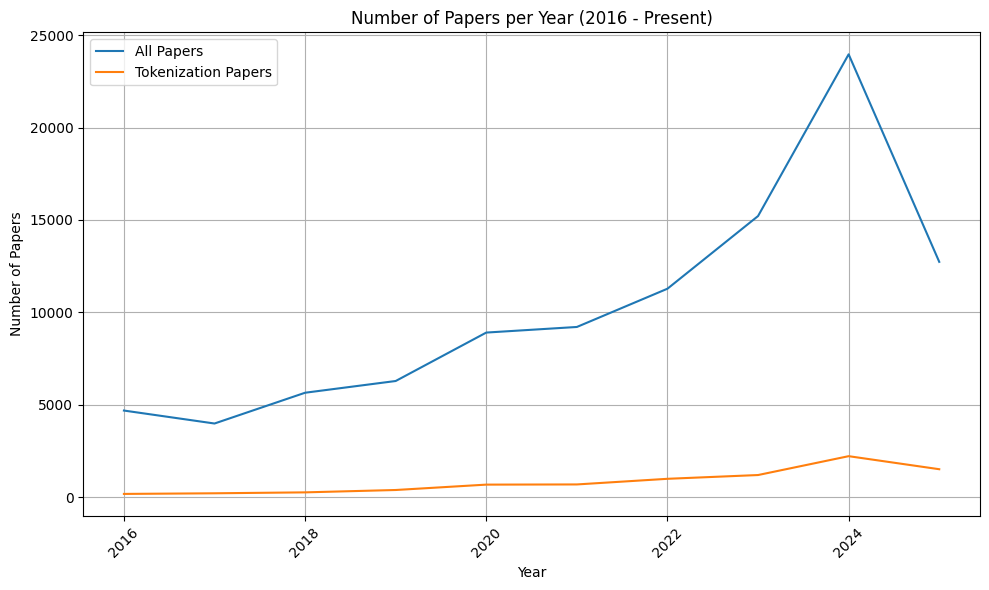

In [6]:
# Plot the number of papers per year
plt.figure(figsize=(10, 6))
recent_counts = recent['year'].value_counts().sort_index()
recent_counts.plot(kind="line")
tokenization_counts = tokenization['year'].value_counts().sort_index()
tokenization_counts.plot(kind="line")
plt.title('Number of Papers per Year (2016 - Present)')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend(['All Papers', 'Tokenization Papers'])
plt.grid(True)
plt.tight_layout()
plt.show()

## Filter with LLM and save the results

This is an initial version of the filtering pipeline.

In [12]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
tqdm.tqdm.pandas()

In [ ]:
# abstracts = tokenization['abstract'].tolist()
# titles = tokenization['title'].tolist()

# tokenization['topic'] = llm_filter.filter_topic(titles, abstracts)
# Merge the tokenization DataFrame with the original DataFrame adding the column 'topic' (bool)
# df = df.merge(tokenization[['bibtex_id', 'topic']], on='bibtex_id', how='left')
# Save df to jsonl file
# df.to_json('topic_papers.jsonl', orient='records', lines=True)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8266/8266 [1:01:39<00:00,  2.23it/s]
/COMP.TMP/vico_5779059/ipykernel_3487670/4142716666.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tokenization['topic'] = tokenization.progress_apply(lambda x: llm_filter.filter_topic(x['abstract'], x['title']), axis=1)


In [ ]:
df = paper_dataset.load('data/topic_papers.jsonl')
# df = paper_dataset.load()
recent = df[df['year'] >= 2016]
real_tokenization = df[df['topic'] == True]

In [7]:
samples = paper_dataset.sample(real_tokenization, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

Title: {M}orfessor-enriched features and multilingual training for canonical morphological segmentation
Author(s): Rouhe, Aku and Gr{\"o}nroos, Stig-Arne and Virpioja, Sami and Creutz, Mathias and Kurimo, Mikko
Year: 2022
Venue: None (ACL)
Volume: Proceedings of the 19th SIGMORPHON Workshop on Computational Research in Phonetics, Phonology, and Morphology
--------------------------------------------------------------------------------
Abstract:
   In our submission to the SIGMORPHON 2022 Shared Task on Morpheme
   Segmentation, we study whether an unsupervised morphological
   segmentation method, Morfessor, can help in a supervised setting.
   Previous research has shown the effectiveness of the approach in
   semisupervised settings with small amounts of labeled data. The current
   tasks vary in data size: the amount of word-level annotated training
   data is much larger, but the amount of sentencelevel annotated training
   data remains small. Our approach is to pre-segment the in

In [13]:
recent = paper_dataset.load()
recent = recent[recent['year'] >= 2016]
keywords = re.compile(r"token|sub-?word|segment")
possible = recent[recent["abstract"].progress_apply(lambda x: x is not None and re.search(keywords, x.lower()) is not None)]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101891/101891 [00:01<00:00, 97636.93it/s]


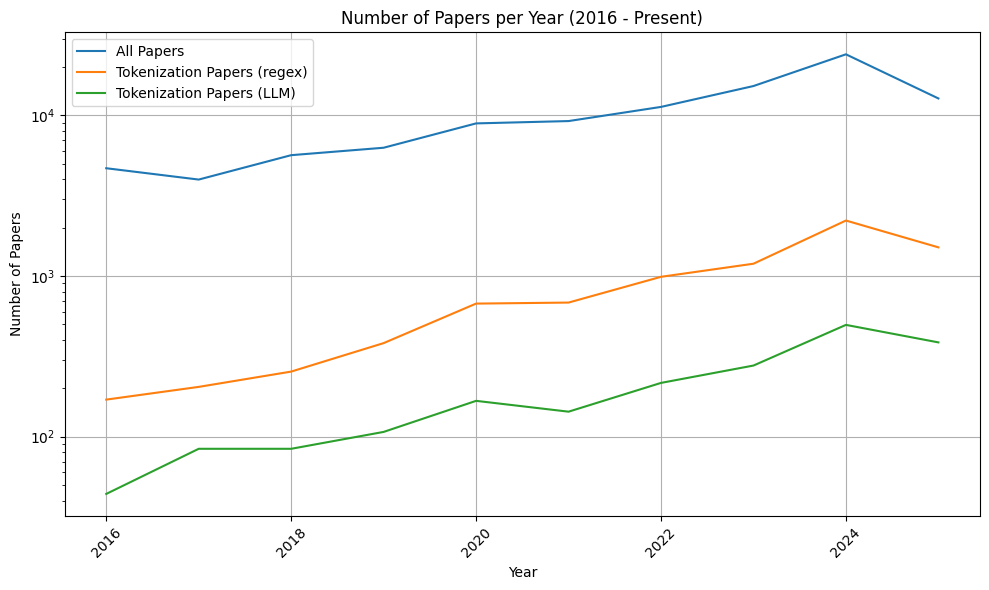

In [14]:
# Plot the number of papers per year
plt.figure(figsize=(10, 6))
recent_counts = recent['year'].value_counts().sort_index()
recent_counts.plot(kind="line", logy=True)
tokenization_counts = possible['year'].value_counts().sort_index()
tokenization_counts.plot(kind="line", logy=True)
real_tokenization_counts = real_tokenization['year'].value_counts().sort_index()
real_tokenization_counts.plot(kind="line", logy=True)
plt.title('Number of Papers per Year (2016 - Present)')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend(['All Papers', 'Tokenization Papers (regex)', 'Tokenization Papers (LLM)'])
plt.grid(True)
plt.tight_layout()
plt.show()

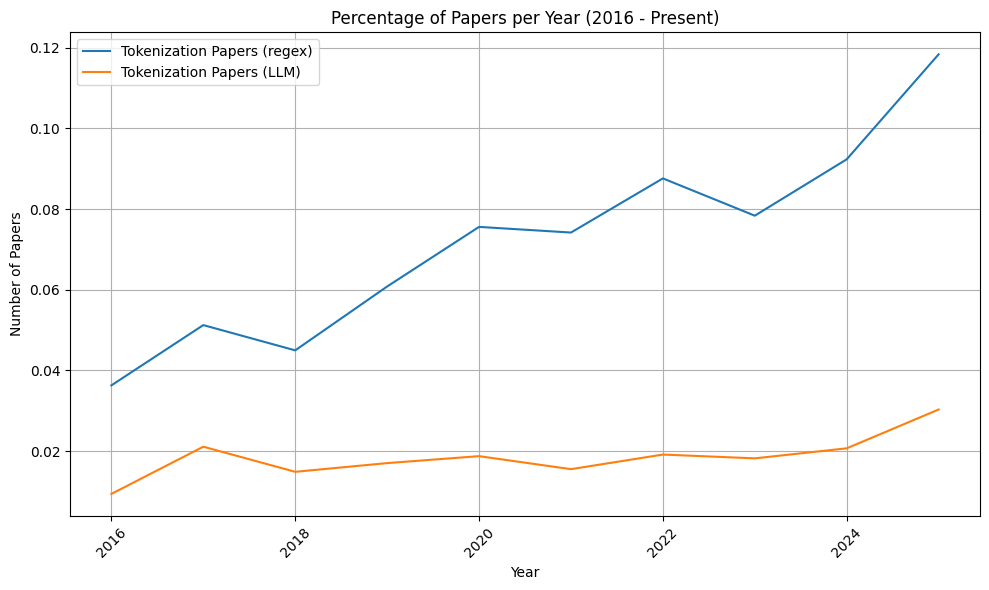

In [15]:
# Plot the number of papers per year
plt.figure(figsize=(10, 6))
recent_counts = recent['year'].value_counts().sort_index()
tokenization_counts = possible['year'].value_counts().sort_index()
(tokenization_counts / recent_counts).plot(kind="line")
real_tokenization_counts = real_tokenization['year'].value_counts().sort_index()
(real_tokenization_counts / recent_counts).plot(kind="line")
plt.title('Percentage of Papers per Year (2016 - Present)')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend(['Tokenization Papers (regex)', 'Tokenization Papers (LLM)'])
plt.grid(True)
plt.tight_layout()
plt.show()

### Count Table

In [9]:
import paper_dataset
import pandas as pd
import re
import tqdm
tqdm.tqdm.pandas()

In [7]:
ds = paper_dataset.load('data/papers_new.jsonl')
ds = ds[(ds['year'] >= 2016) & (ds["year"] <= 2025)]
print(ds.shape)
ds["type"].value_counts()

(113571, 13)


type
acl        74758
neurips    18785
icml       10570
iclr        9159
colm         299
Name: count, dtype: int64

In [10]:
keywords = re.compile(r"token|sub-?word|segment")
possible = ds[ds["abstract"].progress_apply(lambda x: x is not None and re.search(keywords, x.lower()) is not None)]
print(possible.shape)
possible["type"].value_counts()

  0%|                                                                                                                                                                                           | 0/113571 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 113571/113571 [00:01<00:00, 58801.79it/s]

(9540, 13)


type
acl        6407
neurips    1180
iclr       1002
icml        893
colm         58
Name: count, dtype: int64

In [12]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization = real_tokenization[real_tokenization["exclude"] == False]
print(real_tokenization.shape)
real_tokenization["type"].value_counts()

(2090, 20)


type
acl        1497
iclr        209
neurips     190
icml        183
colm         11
Name: count, dtype: int64

## Type of the paper
- Tokeniser/Evaluation/Application/Other

In [3]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import collections
tqdm.tqdm.pandas()

/lnet/work/people/vico/TokSurvey/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 03-07 18:20:58 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 03-07 18:21:03 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


In [2]:
importlib.reload(llm_filter)

<module 'llm_filter' from '/lnet/work/people/vico/TokSurvey/llm_filter.py'>

In [3]:
df = paper_dataset.load('data/topic_papers.jsonl')
real_tokenization = df[df['topic'] == True]
real_tokenization.shape

(2004, 14)

In [ ]:
# llm_filter.test('test_set.json', lambda a, t, c: llm_filter.is_tokeniser(a, t), 'tokenization')
# llm_filter.test('test_set.json', lambda a, t, c: llm_filter.is_evaluation(a, t), 'evaluation')
# llm_filter.test('test_set.json', lambda a, t, c: llm_filter.is_survey(a, t), 'survey')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:27<00:00,  3.10s/it]


Title: ADASPLASH: Adaptive Sparse Flash Attention
Answer: False (Reference: None)
--------------------------------------------------------------------------------
Title: Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: LANGUAGE MODELLING WITH PIXELS
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: Dynamic Chunking for End-to-End Hierarchical Sequence Modeling
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: Tokenization and the Noiseless Channel
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Do All Languages Cost the Same? Tokenization in the Era of Commercial Language Models
Answer: False (Reference: False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:25<00:00,  2.84s/it]


Title: ADASPLASH: Adaptive Sparse Flash Attention
Answer: False (Reference: None)
--------------------------------------------------------------------------------
Title: Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: LANGUAGE MODELLING WITH PIXELS
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Dynamic Chunking for End-to-End Hierarchical Sequence Modeling
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Tokenization and the Noiseless Channel
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: Do All Languages Cost the Same? Tokenization in the Era of Commercial Language Models
Answer: True (Reference: Tru

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:25<00:00,  2.85s/it]

Title: ADASPLASH: Adaptive Sparse Flash Attention
Answer: False (Reference: None)
--------------------------------------------------------------------------------
Title: Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: LANGUAGE MODELLING WITH PIXELS
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Dynamic Chunking for End-to-End Hierarchical Sequence Modeling
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Tokenization and the Noiseless Channel
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Do All Languages Cost the Same? Tokenization in the Era of Commercial Language Models
Answer: False (Reference: 

In [ ]:
# real_tokenization = real_tokenization.copy()

# real_tokenization['tokenization'] = real_tokenization.progress_apply(lambda x: llm_filter.is_tokeniser(x['title'], x['abstract']), axis=1)
# real_tokenization['evaluation'] = real_tokenization.progress_apply(lambda x: llm_filter.is_evaluation(x['title'], x['abstract']), axis=1)
# real_tokenization['survey'] = real_tokenization.progress_apply(lambda x: llm_filter.is_survey(x['title'], x['abstract']), axis=1)
# real_tokenization['application'] = ~(real_tokenization['tokenization'] | real_tokenization['evaluation'] | real_tokenization['survey'])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2004/2004 [09:30<00:00,  3.51it/s]


In [ ]:
# df = paper_dataset.load('data/topic_papers.jsonl')
# df = df.merge(real_tokenization[['bibtex_id', 'tokenization', 'evaluation', 'application', 'survey']], on='bibtex_id', how='left')
# df.to_json('data/papers_with_category.jsonl', orient='records', lines=True)

In [101]:
real_tokenization.to_json('data/real_tokenization.jsonl', orient='records', lines=True)

In [94]:
print("§" * 60)
print("TOKENIZATION")
print("§" * 60)

tmp = df[df['tokenization'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
TOKENIZATION
§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
Title: Plongements lexicaux sp{\'e}cifiques {\`a} la langue arabe : application {\`a} l{'}analyse d{'}opinions ({A}rabic-specific embedddings : application in Sentiment Analysis)
Author(s): Barhoumi, Amira and Camelin, Nathalie and Aloulou, Chafik and Est{\`e}ve, Yannick and Hadrich Belguith, Lamia
Year: 2019
Venue: None (ACL)
Volume: Actes de la Conf{\'e}rence sur le Traitement Automatique des Langues Naturelles (TALN) PFIA 2019. Volume II : Articles courts
--------------------------------------------------------------------------------
Abstract:
   Nous nous int{\'e}ressons, dans cet article, {\`a} la t{\^a}che
   d{'}analyse d{'}opinions en arabe. Nous {\'e}tudions la
   sp{\'e}cificit{\'e} de la langue arabe pour la d{\'e}tection de
   polarit{\'e}. Nous nous focalisons ici sur les caract{\'e}ristiques
   d{'}agglutination et de richesse morphologiq

In [95]:
print("§" * 60)
print("APPLICATION")
print("§" * 60)

tmp = df[df['application'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
APPLICATION
§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
Title: Mitigate Extrinsic Social Bias in Pre-trained Language Models via Continuous Prompts Adjustment
Author(s): Dai, Yiwei and Gu, Hengrui and Wang, Ying and Wang, Xin
Year: 2024
Venue: None (ACL)
Volume: Proceedings of the 2024 Conference on Empirical Methods in Natural Language Processing
--------------------------------------------------------------------------------
Abstract:
   Although pre-trained language models (PLMs) have been widely used in
   natural language understandings (NLU), they are still exposed to
   fairness issues. Most existing extrinsic debiasing methods rely on
   manually curated word lists for each sensitive groups to modify training
   data or to add regular constraints. However, these word lists are often
   limited by length and scope, resulting in the degradation performance of
   extrinsic bias mitigation. To address the

In [96]:
print("§" * 60)
print("EVALUATION")
print("§" * 60)

tmp = df[df['evaluation'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)


§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
EVALUATION
§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
Title: Analyzing Cognitive Plausibility of Subword Tokenization
Author(s): Beinborn, Lisa and Pinter, Yuval
Year: 2023
Venue: None (ACL)
Volume: Proceedings of the 2023 Conference on Empirical Methods in Natural Language Processing
--------------------------------------------------------------------------------
Abstract:
   Subword tokenization has become the de-facto standard for tokenization
   although comparative evaluations of their quality across languages are
   scarce. Existing evaluation studies focus on the effect of a
   tokenization algorithm on the performance in downstream tasks, or on
   engineering criteria such as the compression rate. We present a new
   evaluation paradigm that focuses on the cognitive plausibility of
   subword tokenization. We analyze the correlation of the tokenizer output
   with the reading time and accuracy of hum

In [97]:
print("§" * 60)
print("SURVEY")
print("§" * 60)

tmp = df[df['survey'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
SURVEY
§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
Title: An Assessment of Word Separation Practices in {O}ld {I}rish Text Resources and a Universal Method for Tokenising {O}ld {I}rish Text
Author(s): Doyle, Adrian and McCrae, John P.
Year: 2025
Venue: None (ACL)
Volume: Proceedings of the 5th Celtic Language Technology Workshop
--------------------------------------------------------------------------------
Abstract:
   The quantity of Old Irish text which survives in contemporary
   manuscripts is relatively small by comparison to what is available for
   well-resourced modern languages. Moreover, as it is a historical
   language, no more text will ever be generated by native speakers of Old
   Irish. This makes the text which has survived particularly valuable, and
   ideally, all of it would be annotated using a single, common annotation
   standard, thereby ensuring compatibility between text resources.

In [8]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

(2152, 20)

In [9]:
real_tokenization.columns

Index(['bibtex_id', 'title', 'author', 'year', 'abstract', 'type', 'url',
       'pdf_url', 'volume', 'tldr', 'keywords', 'research_area', 'venue',
       'topic', 'tokenization', 'evaluation', 'survey', 'application',
       'exclude', 'has_code'],
      dtype='object')

Tokenization: 1329
Application: 656
Tokenization+Evaluation: 23
Evaluation: 63
Tokenization+Survey: 8
Tokenization+Evaluation+Survey: 3
Survey: 3
Evaluation+Survey: 5


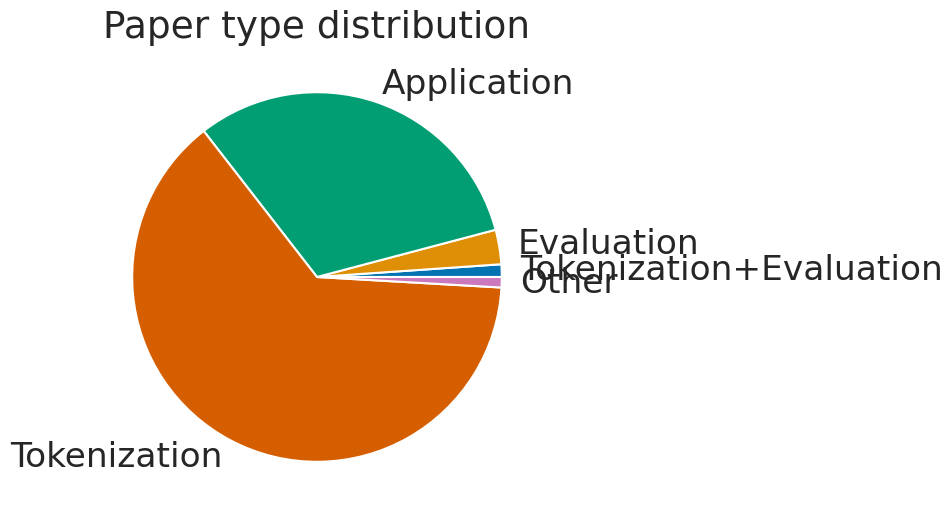

In [10]:
labels = []
years = []
for row in real_tokenization.iloc:
    years.append(row["year"])
    if row["exclude"]:
        continue
    label = []
    if row["tokenization"]:
        label.append("Tokenization")
    if row["evaluation"]:
        label.append("Evaluation")
    if row["survey"]:
        label.append("Survey")
    if row["application"]:
        label.append("Application")
    label = "+".join(label)
    labels.append(label)

counts = collections.Counter(labels)
for i,j in counts.items():
    print(f"{i}: {j}")

k, v = zip(*sorted(counts.most_common(), key=lambda x: x[1], reverse=False))
plt.figure(figsize=(10, 6))
plt.pie(list(v[4:]) + [sum(v[:4])], labels=list(k[4:]) + ["Other"])
# plt.barh(k, v)
plt.title("Paper type distribution")
# plt.xscale("log")
plt.show()



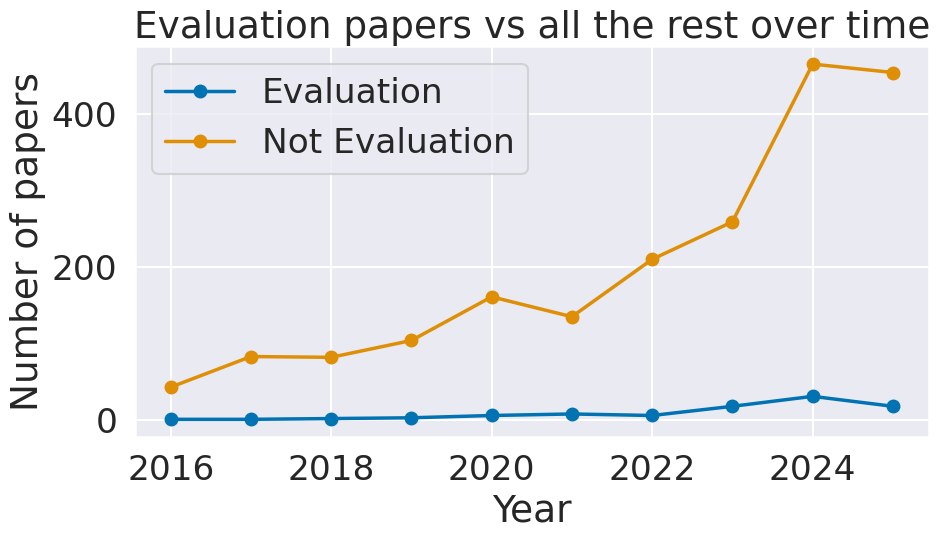

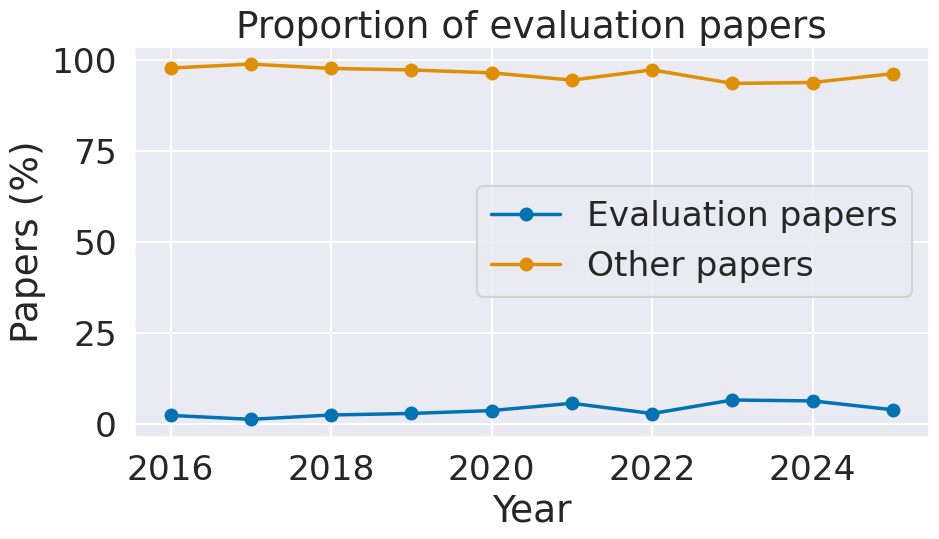

Avg. Evaluation: 3.7174646173235986 %


In [11]:
# Evaluation papers vs all the rest over time, line 

range_years = list(range(2016, 2025+1))
eval_years = collections.Counter([y for l, y in zip(labels, years) if "Evaluation" in l])
eval_counts = [eval_years.get(i, 0) for i in range_years]
not_eval_years = collections.Counter([y for l, y in zip(labels, years) if "Evaluation" not in l])
not_eval_counts = [not_eval_years.get(i, 0) for i in range_years]

plt.figure(figsize=(10, 6))
plt.plot(range_years, eval_counts, marker='o', label="Evaluation")
plt.plot(range_years, not_eval_counts, marker='o', label="Not Evaluation")
plt.title("Evaluation papers vs all the rest over time")
plt.xlabel("Year")
plt.ylabel("Number of papers")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()  

plt.figure(figsize=(10, 6))
plt.plot(range_years, [i/(i+j)*100 if i+j > 0 else 0 for i,j in zip(eval_counts, not_eval_counts)], marker='o', label="Evaluation papers")
plt.plot(range_years, [i/(i+j)*100 if i+j > 0 else 0 for i,j in zip(not_eval_counts, eval_counts)], marker='o', label="Other papers")
plt.title("Proportion of evaluation papers")
plt.xlabel("Year")
plt.ylabel("Papers (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()  
plt.savefig("plots/evaluation_over_time.pdf", bbox_inches='tight')
plt.show()
print("Avg. Evaluation:", sum([i/(i+j)*100 if i+j > 0 else 0 for i,j in zip(eval_counts, not_eval_counts)]) / len(range_years), "%")

## Mark papers with errors and split the dataset

Errors can be pdf no longer available, missing pdf (1 case), pdf encoded as image or not text extracted.
We decide an arbitrary threshold on the Markdown file size (5kb) to filter out papers with no text extracted. This excludes 9 papers, however, papers with small size are often not relevant or are just extended abstracts.

In [38]:
# TODO move this section before the type of papers

In [119]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
tqdm.tqdm.pandas()

In [105]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

(2004, 18)

In [114]:
errors = {
    'tokenization': [],
    'evaluation': [],
    'application': [],
    'survey': []
}

for row in tqdm.tqdm(real_tokenization.iloc, total=len(real_tokenization)):
    try:
        paper_dataset.get_markdown(row['pdf_url'])
    except (ValueError, paper_dataset.pymupdf4llm.pymupdf.FileDataError) as e:
        if row['tokenization']:
            errors['tokenization'].append((row['bibtex_id'], row['pdf_url']))
        if row['evaluation']:
            errors['evaluation'].append((row['bibtex_id'], row['pdf_url']))
        if row['application']:
            errors['application'].append((row['bibtex_id'], row['pdf_url']))
        if row['survey']:
            errors['survey'].append((row['bibtex_id'], row['pdf_url']))
with open('data/missing_papers.json', 'w') as f:
    json.dump(errors, f, indent=2)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2004/2004 [01:03<00:00, 31.65it/s]


In [121]:
missing_urls = list(set.union(*(set(value) for value in errors.values())))
print('Missing:', len(missing_urls))
for e in errors.items():
    print(f"{e[0]}: {len(set(e[1]))}")

Missing: 57
tokenization: 39
evaluation: 4
application: 15
survey: 1


In [116]:
def too_small(x, threshold=5_000, root='data/pdfs/'):
    md = os.path.join(root, paper_dataset.pdf_url_to_file(x) + '.md')
    return (not os.path.exists(md)) or (os.path.getsize(md) < threshold)

In [120]:
real_tokenization['exclude'] = real_tokenization['pdf_url'].apply(lambda x: x == '' or x in missing_urls or too_small(x))
real_tokenization['exclude'].sum()

np.int64(62)

In [122]:
real_tokenization.to_json('data/real_tokenization.jsonl', orient='records', lines=True)

## Code

In [3]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
tqdm.tqdm.pandas()

/lnet/work/people/vico/TokSurvey/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 03-10 10:44:42 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 03-10 10:44:47 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


In [4]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')

In [42]:
def f(x: str):
    if x is None or x == '':
        return False
    try:
        md = paper_dataset.get_markdown(x)
    except (ValueError, paper_dataset.pymupdf4llm.pymupdf.FileDataError):
        return False
    if md is None:
        return False
    return llm_filter.has_pypi(md) or llm_filter.has_repository(md)
real_tokenization['has_code'] = real_tokenization['pdf_url'].progress_apply(f) & ~real_tokenization['exclude']
print(
    real_tokenization['has_code'].sum(),
    'papers with code out of', 
    len(real_tokenization),
    f"({real_tokenization['has_code'].sum()/len(real_tokenization)*100:.1f}%)"
)
# real_tokenization.to_json('data/real_tokenization.jsonl', orient='records', lines=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2152/2152 [00:37<00:00, 57.11it/s]

1173 papers with code out of 2152 (54.5%)


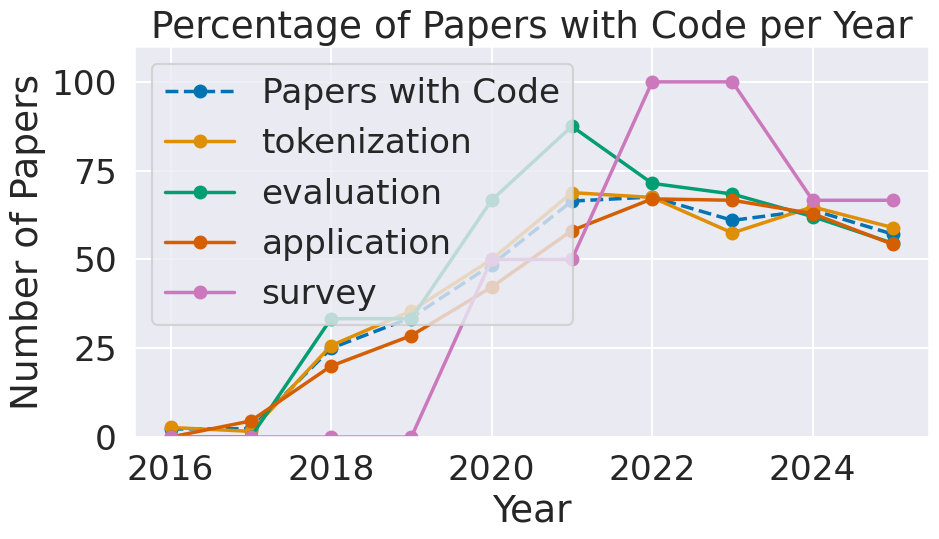

In [43]:
# Plot the number of papers with code over the years
years = sorted(real_tokenization['year'].unique())
code_counts = []
total_counts = []       
plt.figure(figsize=(10, 6))

for year in years:  
    year_data = real_tokenization[real_tokenization['year'] == year]
    code_count = year_data[year_data['has_code'] == True].shape[0]
    total_count = year_data.shape[0]
    code_counts.append(code_count)
    total_counts.append(total_count)
plt.plot(years, [c/t * 100 if t != 0 else 0 for c, t in zip(code_counts, total_counts)], marker='o', linestyle='--', label='Papers with Code')

for cat in ['tokenization', 'evaluation', 'application', 'survey']:
    code_counts = []
    total_counts = []  
    for year in years:
        year_data = real_tokenization[(real_tokenization[cat]) & (real_tokenization['year'] == year)]
        code_count = year_data[year_data['has_code'] == True].shape[0]
        total_count = year_data.shape[0]
        code_counts.append(code_count)
        total_counts.append(total_count)
    plt.plot(years, [c/t * 100 if t != 0 else 0 for c, t in zip(code_counts, total_counts)], marker='o', label=cat)


plt.title('Percentage of Papers with Code per Year')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.ylim(0, 110)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("plots/papers_with_code_over_time.pdf", bbox_inches='tight')
plt.show()

acl [1, 1, 21, 34, 80, 84, 134, 140, 161, 148] [44, 82, 83, 103, 166, 126, 198, 226, 253, 230]
icml [0, 0, 0, 0, 0, 0, 0, 5, 38, 47] [0, 0, 0, 0, 0, 0, 0, 13, 73, 144]
iclr [0, 0, 0, 0, 0, 0, 0, 0, 39, 110] [0, 0, 0, 0, 0, 0, 0, 0, 50, 160]
neurips [0, 1, 0, 2, 1, 11, 12, 24, 71, 0] [0, 2, 1, 4, 1, 17, 18, 38, 109, 0]
colm [0, 0, 0, 0, 0, 0, 0, 0, 8, 0] [0, 0, 0, 0, 0, 0, 0, 0, 11, 0]


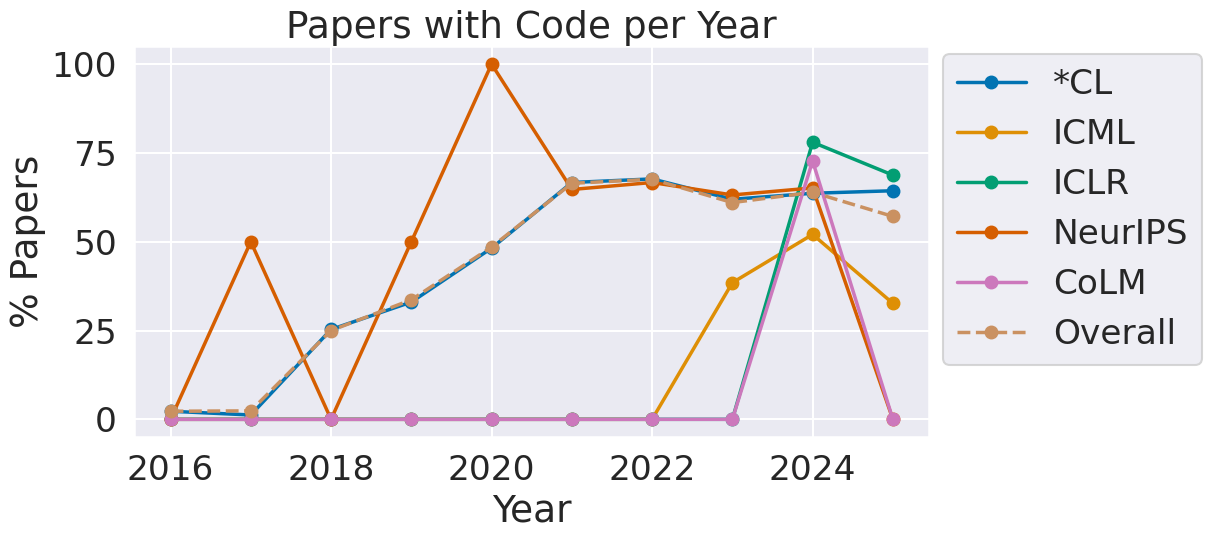

In [47]:
# Plot percentage of papers with code, group by venue
from sympy import li


venue_map = {
    'acl': '*CL',
    'icml': 'ICML',
    'iclr': 'ICLR',
    'neurips': 'NeurIPS',
    'colm': 'CoLM',
}

plt.figure(figsize=(10, 6))
venues = real_tokenization['type'].value_counts().index.tolist()
years = list(range(2016, 2026))
for venue in venues:
    code = []
    total = []
    for year in years:
        year_data = real_tokenization[(real_tokenization['type'] == venue) & (real_tokenization['year'] == year)]
        code.append(year_data[year_data['has_code'] == True].shape[0])
        total.append(year_data.shape[0])
    print(venue, code, total)
    plt.plot(years, [c/t * 100 if t != 0 else 0 for c, t in zip(code, total)], marker='o', label=venue_map.get(venue, venue))
# Plot the overall percentage of papers with code
code_counts = []
total_counts = []
for year in years: 
    year_data = real_tokenization[real_tokenization['year'] == year]
    code_counts.append(year_data[year_data['has_code'] == True].shape[0])
    total_counts.append(year_data.shape[0])
plt.plot(years, [c/t * 100 if t != 0 else 0 for c, t in zip(code_counts, total_counts)], marker='o', linestyle='--', label='Overall')
plt.title('Papers with Code per Year')
plt.xlabel('Year')
plt.ylabel('% Papers')
# plt.xticks(rotation=45)
# plt.gca().figure.legend(loc="outside lower center", ncols=3, bbox_to_anchor=(0.5, -0.1))
plt.gca().figure.legend(loc="outside right center", ncols=1, bbox_to_anchor=(1.25, 0.6))
plt.grid(True)
plt.tight_layout()
# plt.savefig("plots/papers_with_code_by_venue_over_time.pdf", bbox_inches='tight')
plt.show()

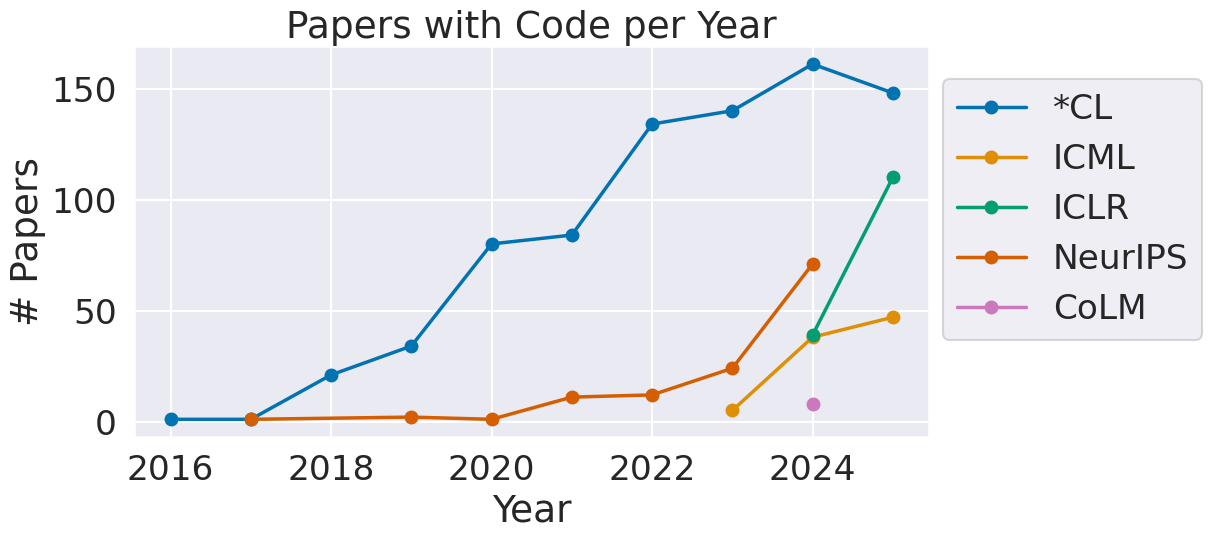

In [46]:
# Plot number papers with code, group by venue
from sympy import li


venue_map = {
    'acl': '*CL',
    'icml': 'ICML',
    'iclr': 'ICLR',
    'neurips': 'NeurIPS',
    'colm': 'CoLM',
}

plt.figure(figsize=(10, 6))
venues = real_tokenization['type'].value_counts().index.tolist()
years = list(range(2016, 2026))
for venue in venues:
    venue_data = real_tokenization[(real_tokenization['type'] == venue) & (real_tokenization['has_code'] == True)]
    
    venue_counts = venue_data['year'].value_counts().sort_index()
    plt.plot(venue_counts.index, venue_counts.values, marker='o', label=venue_map.get(venue, venue))    
    
plt.title('Papers with Code per Year')
plt.xlabel('Year')
plt.ylabel('# Papers')
# plt.gca().figure.legend(loc="outside lower center", ncols=3, bbox_to_anchor=(0.5, -0.1))
plt.gca().figure.legend(loc="outside right center", ncols=1, bbox_to_anchor=(1.25, 0.6))
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/papers_with_code_by_venue_over_time.pdf", bbox_inches='tight')
plt.show()

## Units

- Frequency of each unit
- Number of different units for each paper
- Number of papers using each unit over time

In [3]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
import itertools
import collections
tqdm.tqdm.pandas()

/lnet/work/people/vico/TokSurvey/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 03-11 17:23:10 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 03-11 17:23:15 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


In [4]:
importlib.reload(llm_filter)

<module 'llm_filter' from '/lnet/work/people/vico/TokSurvey/llm_filter.py'>

In [5]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

(2152, 20)

In [6]:
# all_answers_unit = []
# for answer in llm_filter.get_units(real_tokenization):
#     all_answers_unit.append(answer)
    
# with open('data/raw_answers/unit_answer.json', 'wt') as f:
#     json.dump(all_answers_unit, f, indent=2)

In [7]:
with open('data/raw_answers/unit_answer.json') as f:
    all_answers_unit = json.load(f)
all_answers_unit[:5]

['* Words\n* Subwords\n* Characters\n* Bytes\n* Morphemes\n* Phonemes \n* Pitch tokens\n* Style tokens \n* HuBERT tokens',
 '* Tokens \n* Words',
 '* Subwords \n* Tokens \n* Characters \n* Bytes',
 '* Morphemes \n* Subwords \n* Words',
 '* words \n* tokens \n* characters \n* subwords \n* lemmas']

In [8]:
unit_sets = [llm_filter.extract_units(i) for i in all_answers_unit]
unit_sets[:5]

[['bytes',
  'characters',
  'hubert tokens',
  'morphemes',
  'phonemes',
  'pitch tokens',
  'style tokens',
  'subwords',
  'words'],
 ['subwords', 'words'],
 ['bytes', 'characters', 'subwords'],
 ['morphemes', 'subwords', 'words'],
 ['characters', 'lemmas', 'subwords', 'words']]

In [9]:
unique_units = collections.Counter(itertools.chain.from_iterable(unit_sets))
len(unique_units)

707

In [10]:
for i in unique_units.most_common():
    print(i)

('subwords', 1855)
('characters', 1247)
('words', 1236)
('morphemes', 439)
('bytes', 420)
('pixels', 177)
('phonemes', 69)
('sentences', 61)
('patches', 54)
('syllables', 40)
('frames', 35)
('n-grams', 34)
('embeddings', 30)
('phrases', 28)
('nodes', 23)
('image tokens', 20)
('edges', 15)
('stems', 13)
('lemmas', 12)
('entities', 12)
('chunks', 12)
('roots', 11)
('suffixes', 11)
('spans', 10)
('sequences', 9)
('residues', 9)
('atoms', 9)
('graphemes', 8)
('strings', 8)
('bigrams', 8)
('amino acids', 8)
('latent tokens', 8)
('substrings', 7)
('affixes', 7)
('subgraphs', 7)
('subsequences', 7)
('documents', 7)
('lines', 6)
('acoustic tokens', 6)
('actions', 6)
('blocks', 6)
('symbols', 6)
('images', 6)
('vectors', 6)
('graphs', 6)
('digits', 5)
('signs', 5)
('paragraphs', 5)
('sub-tokens', 5)
('prefixes', 5)
('nucleotides', 5)
('samples', 5)
('clips', 5)
('genes', 5)
('latents', 5)
('passages', 4)
('vision tokens', 4)
('logograms', 4)
('windows', 4)
('edus', 4)
('propositions', 4)
('labe

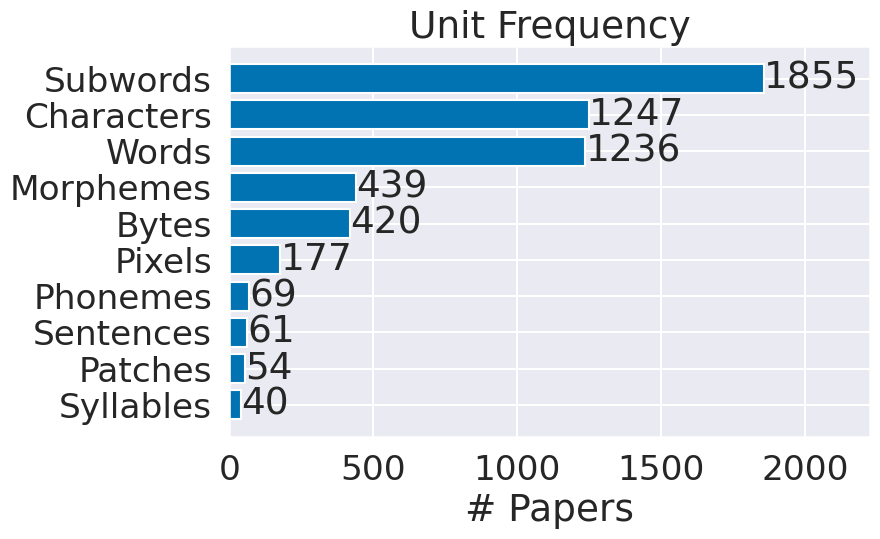

In [62]:
# Plot how many times each unit appears appears in the papers
unit_frequency = collections.Counter()
for units in unit_sets:
    unit_frequency.update(units)
unit_frequency_items = unit_frequency.most_common(10)
units, frequencies = zip(*unit_frequency_items)
plt.figure(figsize=(10, 6))
plt.barh(list(map(str.capitalize, units[::-1])), frequencies[::-1])
plt.title('Unit Frequency')
# Add the frequency values to the bars
for i, v in enumerate(frequencies[::-1]):
    plt.text(v + 0.5, i, str(v), va='center')
plt.xlabel('# Papers')
plt.tight_layout()
plt.xlim(0, max(frequencies)*1.2)
plt.savefig("plots/unit_frequency.pdf", bbox_inches='tight')
plt.show()

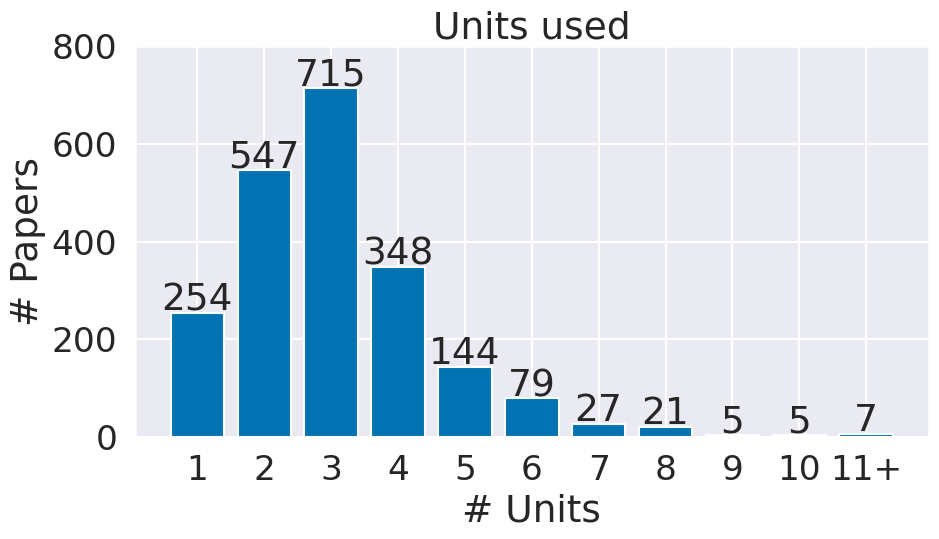

In [63]:
# Types of units per paper
max_ = 11
counts = [len(units) for units in unit_sets]
if max_ in counts:
    raise ValueError("max_ value is in counts, choose a higher value")
counts = [c if c <= max_ else max_ for c in counts]
plt.figure(figsize=(10, 6))
plt.hist(counts, bins=range(1, max_ + 2), align='left', rwidth=0.8)
plt.xticks(range(1, max_ + 1), labels=[str(i) for i in range(1, max_)] + [f"{max_}+"] )
plt.xlabel('# Units')
plt.ylabel('# Papers')
plt.title('Units used')
# Add the count values on top of the bars
for i in range(1, max_ + 1):
    count = counts.count(i)
    plt.text(i, count + 5, str(count), ha='center')
plt.ylim(0, 800)
plt.tight_layout()
plt.savefig("plots/number_of_unit_types.pdf", bbox_inches='tight')
plt.show()

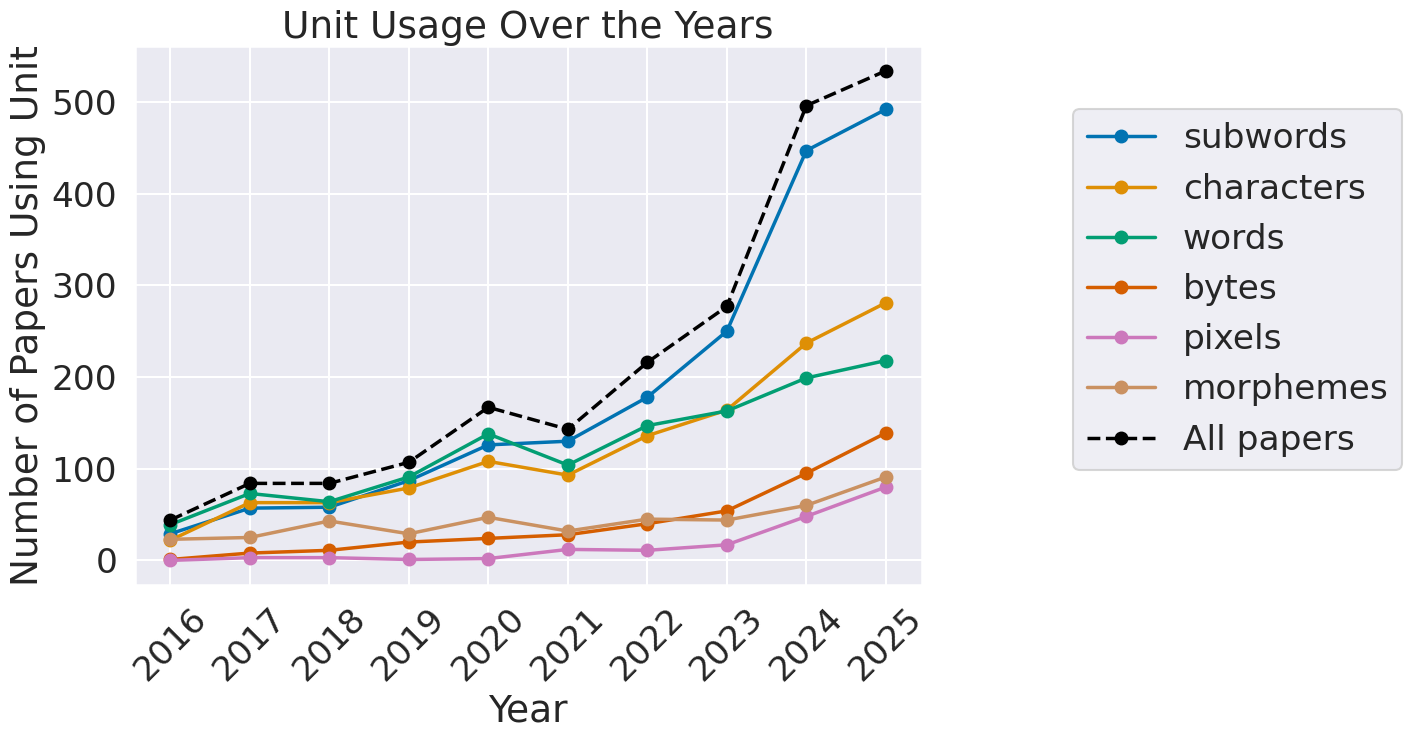

In [69]:
# Count how many times units are used over the years
# Units: subwords, characters, words, bytes, pixels, morphemes
years = real_tokenization.year.to_list()
year_range = list(range(min(years), max(years) + 1))
min_ = min(year_range)
units = ["subwords", "characters", "words", "bytes", "pixels", "morphemes"]
counts = {unit: [0] * len(year_range) for unit in units}
all_counts = [0] * len(year_range)
for unit_set, year in zip(unit_sets, years):
    for unit in units:
        if unit in unit_set:
            counts[unit][year - min_] += 1
    all_counts[year - min_] += 1
plt.figure(figsize=(10, 8))
for unit in units:
    plt.plot(year_range, counts[unit], marker='o', label=unit)
plt.plot(year_range, all_counts, marker='o', label='All papers', linestyle='--', color='black')
    
plt.title('Unit Usage Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Papers Using Unit')
plt.xticks(year_range, rotation=45)
# plt.legend()
plt.gca().figure.legend(loc="outside right center", ncols=1, bbox_to_anchor=(1.45, 0.6))
plt.grid(True)
plt.tight_layout()
plt.show()    

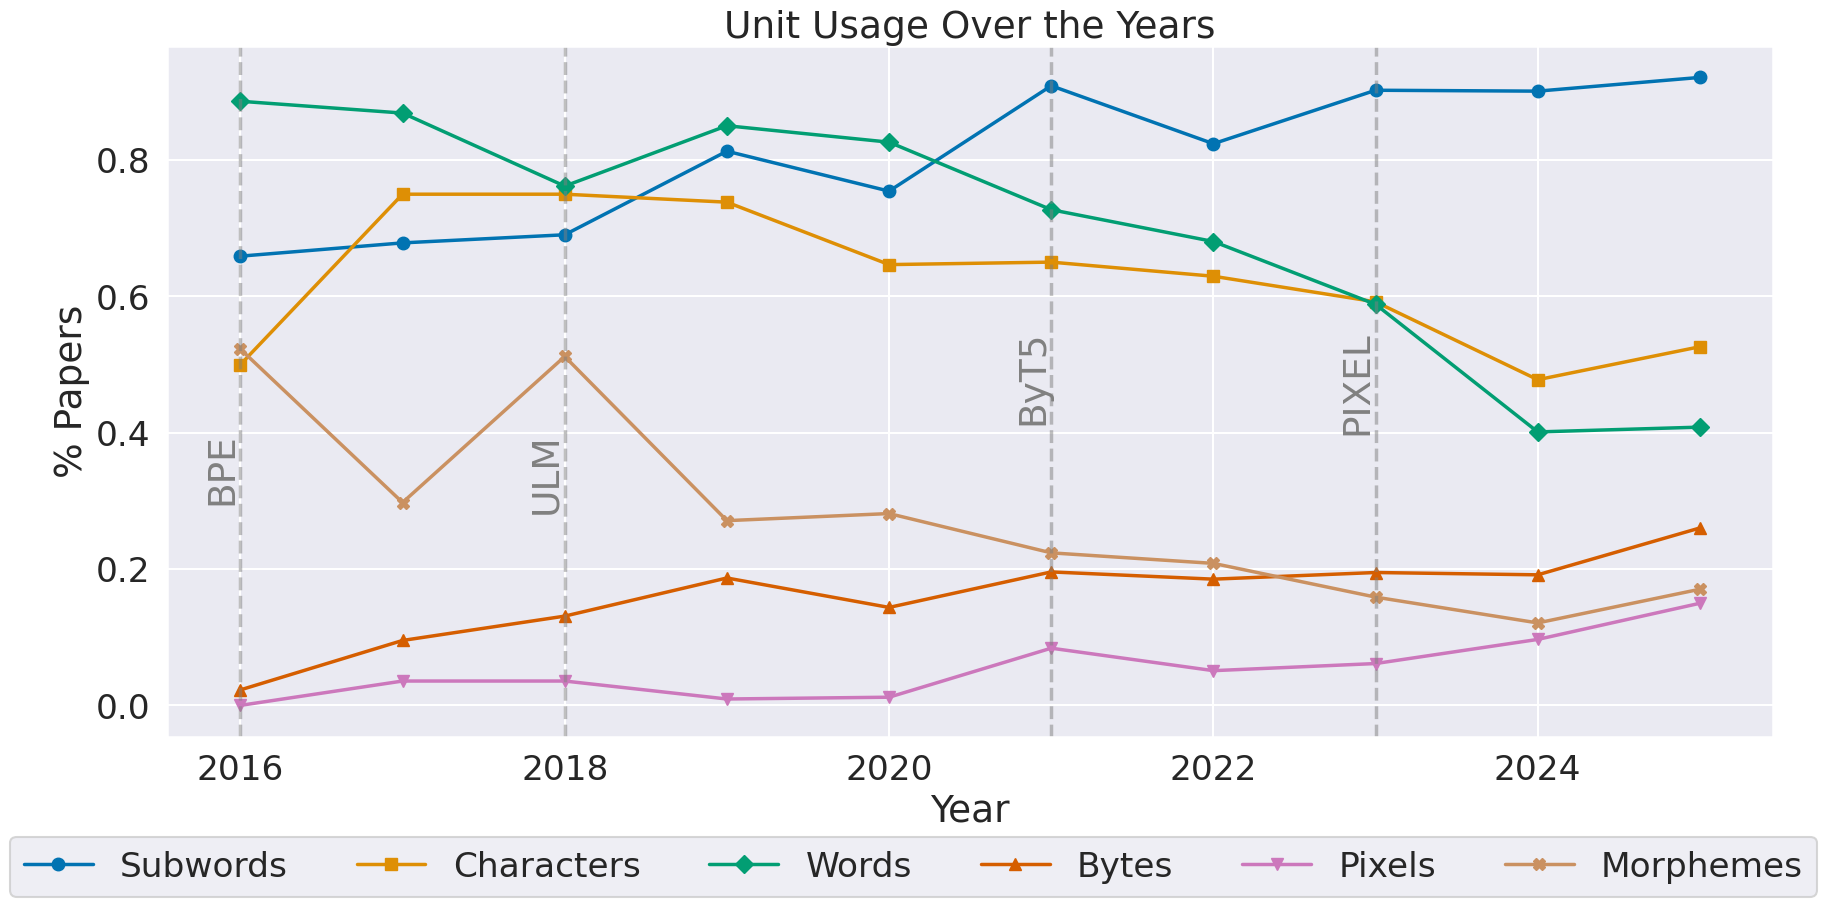

In [15]:
# Count how many times units are used over the years
# Units: subwords, characters, words, bytes, pixels, morphemes
from matplotlib import markers


years = real_tokenization.year.to_list()
year_range = list(range(min(years), max(years) + 1))
min_ = min(year_range)
units = ["subwords", "characters", "words", "bytes", "pixels", "morphemes"]
counts = {unit: [0] * len(year_range) for unit in units}
all_counts = [0] * len(year_range)
for unit_set, year in zip(unit_sets, years):
    for unit in units:
        if unit in unit_set:
            counts[unit][year - min_] += 1
    all_counts[year - min_] += 1
plt.figure(figsize=(18, 9))
markers = ['o', 's', 'D', '^', 'v', 'X']
for unit, marker in zip(units, markers):
    plt.plot(year_range, [i/j if j > 0 else 0 for i, j in zip(counts[unit], all_counts)], marker=marker, label=unit.capitalize())
# Add milestones
milestones = [
    (2016, 'BPE', 0.40),
    (2018, 'ULM', 0.40),
    (2021, 'ByT5', 0.55),
    (2023, 'PIXEL', 0.55)
]
for year, label, y in milestones:
    plt.axvline(x=year, color='gray', linestyle='--', alpha=0.5)
    plt.text(year, y, label, verticalalignment='top', horizontalalignment='right', color='gray', rotation=90)
plt.title('Unit Usage Over the Years')
plt.xlabel('Year')
plt.ylabel('% Papers')
# plt.xticks(year_range)
plt.gca().figure.legend(loc="outside lower center", ncols=6, bbox_to_anchor=(0.5, -0.05))
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/unit_usage_percentage_over_time.pdf", bbox_inches='tight')
plt.show()    

In [28]:
tmp = [i for i in unit_frequency.keys() if 'token' in i]
len(set(tmp))

108

In [29]:
tmp[:10]

['hubert tokens',
 'pitch tokens',
 'style tokens',
 'draft token sequence',
 'prefix tokens',
 'subsequent tokens',
 'token sequences',
 'language tokens',
 'vision tokens',
 'image tokens']

## Metrics

In [112]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
import collections
import itertools
import pandas as pd
tqdm.tqdm.pandas()

In [99]:
importlib.reload(llm_filter)

<module 'llm_filter' from '/lnet/work/people/vico/TokSurvey/llm_filter.py'>

In [113]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

(2152, 20)

In [114]:
# all_answers_task_metric = []
# for answer in llm_filter.get_metrics_tasks(real_tokenization):
#     all_answers_task_metric.append(answer)
    
# with open('data/raw_answers/metrics_tasks_answer.json', 'wt') as f:
#     json.dump(all_answers_task_metric, f, indent=2)

In [115]:
with open('data/raw_answers/metrics_tasks_answer.json') as f:
    all_answers_task_metric = json.load(f)
all_answers_task_metric[:5]

['* Tokenization: Word Error Rate (WER), Character Error Rate (CER), Bitrate, Content, Expressive Style, Pitch, F0 Frame Error (FFE)\n* Language Modeling: Accuracy, Accuracy-token, Log-likelihood, Perplexity\n* Speech Recognition: Word Error Rate (WER)\n* Text-to-Speech: Character Error Rate (CER)\n* Sentiment Preservation: Accuracy\n* Intent Classification: Accuracy\n* Story Cloze: Accuracy\n* WUGGY: Accuracy\n* BLIMP: Accuracy\n* MMLU: Accuracy',
 '* Speculative Decoding: Mean Acceptance Length, Tokens per Second, Speedup Ratio \n* Tree Construction: Mathematical Expectation of Acceptance Length \n* Drafting: Output Probability, Acceptance Frequency \n* Verification: Acceptance Length, Verification Time \n* Evaluation: Mean Acceptance Length, Tokens per Second, Speedup Ratio \n* Analysis: Time Cost, Threshold Impact \n* Comparison: Mean Acceptance Length, Tokens per Second, Speedup Ratio',
 '* Tokenization Efficiency: Length Per Token (LPT)\n* Task Performance: Exact Match (EM), Char

In [116]:
metric_sets = [llm_filter.extract_tasks_metrics(i) for i in all_answers_task_metric]
metric_sets[:5]

[{'tokenization': ['content',
   'bitrate',
   'expressive style',
   'f0 frame error (ffe)',
   'pitch',
   'character error rate',
   'word error rate'],
  'language modeling': ['log-likelihood', 'accuracy', 'perplexity'],
  'speech recognition': ['word error rate'],
  'text-to-speech': ['character error rate'],
  'sentiment preservation': ['accuracy'],
  'intent classification': ['accuracy'],
  'story cloze': ['accuracy'],
  'wuggy': ['accuracy'],
  'blimp': ['accuracy'],
  'mmlu': ['accuracy']},
 {'decoding': ['speedup', 'tokens per second', 'mean acceptance length'],
  'tree construction': ['mathematical expectation of acceptance length'],
  'drafting': ['output probability', 'acceptance frequency'],
  'verification': ['verification time', 'acceptance length'],
  'model evaluation': ['speedup',
   'tokens per second',
   'mean acceptance length']},
 {'tokenization efficiency': ['length per token (lpt)'],
  'task performance': ['f1 score', 'accuracy', 'bertscore', 'exact match'],
 

In [117]:
tmp = [list(i.keys()) for i in metric_sets]
tmp = set(itertools.chain.from_iterable(tmp))
tmp

{'related work',
 'adjustment evaluation',
 'affective computing',
 'out-of-vocabulary (oov) robustness',
 'exponential smoothing',
 'extrinsic evaluation',
 'efficiency gain',
 'natural language processing for low-resource languages',
 'adaptation to new variables',
 'unbounded cache evaluation',
 'acronym generation',
 'hallucination alleviation',
 'joint bilingual learning of bpe units',
 'multi-document question answering',
 'cross-lingual text classification',
 'sentiment prediction',
 'linear text segmentation',
 'cross-lingual coreference resolution',
 'stylistic similarity',
 'model inference',
 'transfer capability',
 'specific tasks',
 'paraphrase',
 'rare token extraction',
 'nonspecificility',
 'vocabulary initialization',
 'phonetic typology',
 'speed analysis',
 'token-level matching',
 'orthographic knowledge',
 'search result re-ranking',
 'vocabulary optimization',
 'series domain analysis',
 'layer selection',
 'tokenizer swapping',
 'amplification comprehensive perfo

Tasks: 6256
Papers with task with no metrics: 65
Tasks with no metrics: 131


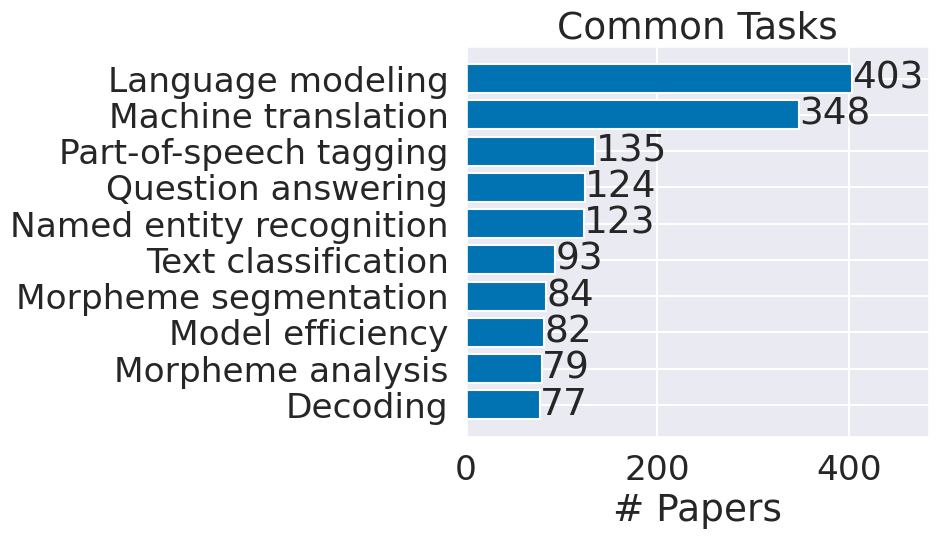

In [143]:
remove = ["tokenization", "ablation study", "model evaluation"]
task_frequency = collections.Counter()
tasks_no_metric = set()
paper_task_no_metric = 0
exclude = real_tokenization['exclude'].to_list()
for metrics, ex in zip(metric_sets, exclude):
    if not ex:
        task_frequency.update(metrics.keys())
        if [] in metrics.values():
            paper_task_no_metric += 1
            for task, metric_list in metrics.items():
                if len(metric_list) == 0:
                    tasks_no_metric.add(task)
        
print("Tasks:", len(task_frequency))
print("Papers with task with no metrics:", paper_task_no_metric)
print("Tasks with no metrics:", len(tasks_no_metric))
# for i in task_frequency.most_common(20):
#     print(i)
# Plot most common tasks
for task in remove:
    if task in task_frequency:
        del task_frequency[task]
most_common_task = task_frequency.most_common(10)
tasks, counts = zip(*most_common_task)
tasks = [t.capitalize() for t in tasks]
plt.figure(figsize=(10, 6))
plt.barh(tasks, counts)
plt.gca().invert_yaxis()
plt.title('Common Tasks')
plt.xlabel('# Papers')
# Add the frequency values to the bars
for i, v in enumerate(counts):
    plt.text(v + 0.5, i, str(v), va='center')
plt.xlim(0, max(counts)*1.2)
plt.tight_layout()
plt.savefig("plots/most_common_tasks.pdf", bbox_inches='tight')
plt.show()

Metrics: 5492


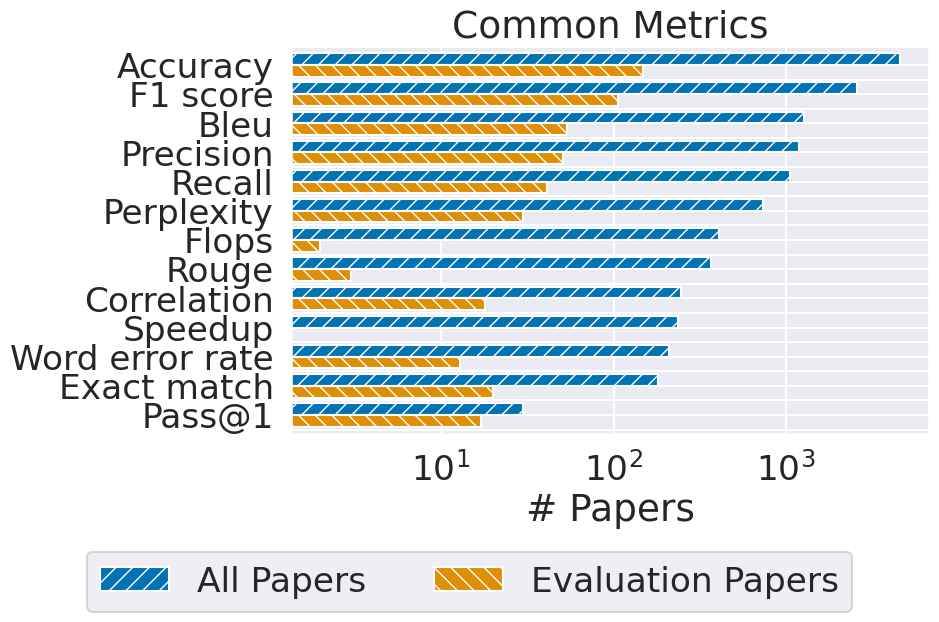

In [176]:
from matplotlib import legend


metric_frequency = collections.Counter()
eval_metric_frequency = collections.Counter()
survey_metric_frequency = collections.Counter()
tok_metric_frequency = collections.Counter()
for metrics, info in zip(metric_sets, real_tokenization.iloc):
    ev = info['evaluation']
    sv = info['survey']
    tk = info['tokenization']
    for metric_list in metrics.values():
        metric_frequency.update(metric_list)
        if ev:
            eval_metric_frequency.update(metric_list)
        if sv:
            survey_metric_frequency.update(metric_list)
        if tk:
            tok_metric_frequency.update(metric_list)
print("Metrics:", len(metric_frequency))

# Plot most common metrics, grouped by category
n = 10
most_common_metric = metric_frequency.most_common(n)
# tok_common_metric = tok_metric_frequency.most_common(n)
eval_common_metric = eval_metric_frequency.most_common(n)
# survey_common_metric = survey_metric_frequency.most_common(n)

metrics, _ = zip(*most_common_metric)
# tok_metrics, _ = zip(*tok_common_metric)
eval_metrics, _ = zip(*eval_common_metric)
# survey_metrics, _ = zip(*survey_common_metric)

# plot_metrics = list(set(metrics) | set(tok_metrics) | set(eval_metrics) | set(survey_metrics))
plot_metrics = list(set(metrics) | set(eval_metrics))
counts = [metric_frequency[m] for m in plot_metrics]
plot_metrics = sorted(plot_metrics, key=lambda x: metric_frequency[x], reverse=True)
counts = [metric_frequency[m] for m in plot_metrics]

# tok_counts = [tok_metric_frequency[m] for m in plot_metrics]
eval_counts = [eval_metric_frequency[m] for m in plot_metrics]
# survey_counts = [survey_metric_frequency[m] for m in plot_metrics]

plot_metrics = [m.capitalize() for m in plot_metrics]
df = pd.DataFrame({
    'Metric': plot_metrics,
    'All Papers': counts,
    # 'Tokenization Papers': tok_counts,
    'Evaluation Papers': eval_counts,
    # 'Survey Papers': survey_counts
})  

ax = df.plot.barh(layout='tight', figsize=(10, 6), width=0.8, legend=False)
patches = ["//"] * len(df) + ["\\\\"] * len(df)
for patch, p in zip(patches, ax.patches):
    p.set_hatch(patch)
plt.xlabel('# Papers')
plt.xscale('log')
# plt.ylabel('Metrics')
plt.yticks(range(len(plot_metrics)), labels=plot_metrics)
plt.yticks([i+0.5 for i in range(len(plot_metrics))], minor=True)
plt.grid(which='minor', axis='y')
plt.title('Common Metrics')
plt.gca().invert_yaxis()
# plt.legend()
plt.gca().figure.legend(loc="outside lower center", ncols=2, bbox_to_anchor=(0.5, -0.1))
plt.tight_layout()
plt.savefig("plots/most_common_metrics.pdf", bbox_inches='tight')
plt.show()

Papers with intrinsic tasks: 598
Papers with extrinsic tasks: 2153


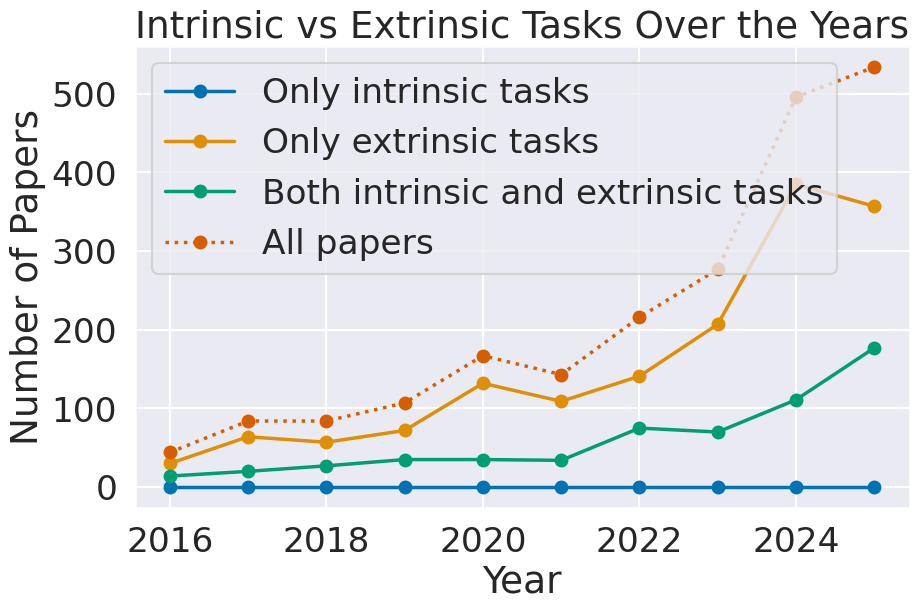

In [140]:
intrinsic_tasks = ['language modeling', 'word segmentation', 'segmentation', 'morpheme segmentation', 'subwording', 'model efficiency']
is_intrinsic = []
is_extrinsic = []
for metrics in metric_sets:
    if len(metrics) == 0:
        is_intrinsic.append(False)
        is_extrinsic.append(False)
    else:
        tasks = list(metrics.keys())
        has_intrinsic = any(intrinsic_task in tasks for intrinsic_task in intrinsic_tasks)
        is_intrinsic.append(has_intrinsic)
        has_extrinsic = any(intrinsic_task not in tasks for intrinsic_task in intrinsic_tasks)
        is_extrinsic.append(has_extrinsic)
print("Papers with intrinsic tasks:", sum(is_intrinsic))
print("Papers with extrinsic tasks:", sum(is_extrinsic))
years = real_tokenization.year.to_list()
year_range = list(range(min(years), max(years) + 1))
min_ = min(year_range)
int_only_counts = [0] * len(year_range)
ext_only_counts = [0] * len(year_range)
int_ext_counts = [0] * len(year_range)
all_counts = [0] * len(year_range)
for intrinsic, extrinsic, year in zip(is_intrinsic, is_extrinsic, years):
    if intrinsic and extrinsic:
        int_ext_counts[year - min_] += 1
    elif intrinsic:
        int_only_counts[year - min_] += 1
    elif extrinsic:
        ext_only_counts[year - min_] += 1    
    all_counts[year - min_] += 1
plt.figure(figsize=(10, 6))
plt.plot(year_range, int_only_counts, marker='o', label='Only intrinsic tasks')
plt.plot(year_range, ext_only_counts, marker='o', label='Only extrinsic tasks')
plt.plot(year_range, int_ext_counts, marker='o', label='Both intrinsic and extrinsic tasks')
plt.plot(year_range, all_counts, marker='o', linestyle=":", label='All papers')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.title('Intrinsic vs Extrinsic Tasks Over the Years')
plt.legend()
plt.grid(True)
plt.show()

In [142]:
print("Papers with only intrinsic tasks:", sum(int_only_counts)/sum(all_counts)*100, "%")
print("Papers with only extrinsic tasks:", sum(ext_only_counts)/sum(all_counts)*100, "%")
print("Papers with both intrinsic and extrinsic tasks:", sum(int_ext_counts)/sum(all_counts)*100, "%")

Papers with only intrinsic tasks: 0.0 %
Papers with only extrinsic tasks: 72.21189591078067 %
Papers with both intrinsic and extrinsic tasks: 27.788104089219328 %


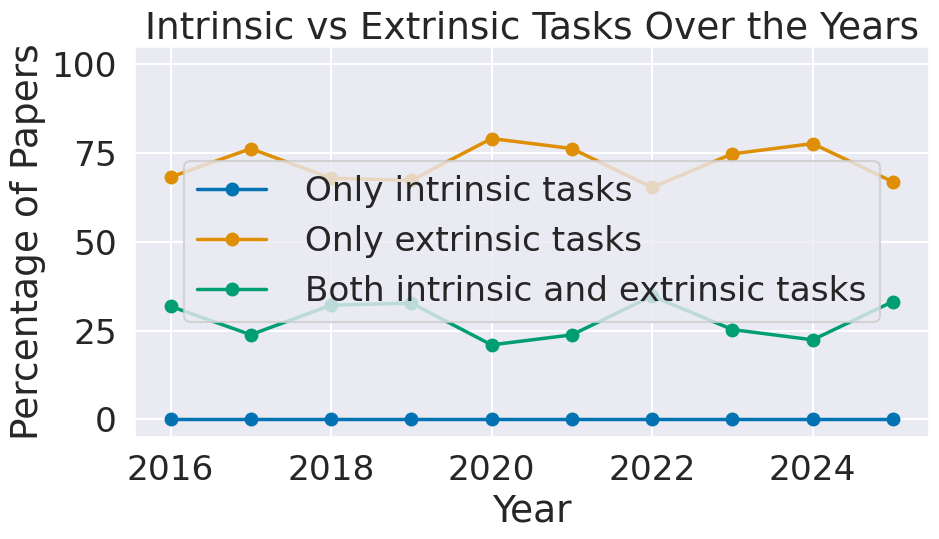

In [ ]:
# Plot the percentage of intrinsic and extrinsic tasks over the years
plt.figure(figsize=(10, 6))
plt.plot(year_range, [i/j * 100 if j > 0 else 0 for i, j in zip(int_only_counts, all_counts)], marker='o', label=' Only intrinsic tasks')
plt.plot(year_range, [i/j * 100 if j > 0 else 0 for i, j in zip(ext_only_counts, all_counts)], marker='o', label=' Only extrinsic tasks')
plt.plot(year_range, [i/j * 100 if j > 0 else 0 for i, j in zip(int_ext_counts, all_counts)], marker='o', label=' Both intrinsic and extrinsic tasks')
plt.xlabel('Year')
plt.ylabel('Percentage of Papers')
plt.title('Intrinsic vs Extrinsic Tasks Over the Years')
plt.legend()
plt.grid(True)
plt.ylim(-5, 105)
plt.tight_layout()
plt.savefig("plots/intrinsic_extrinsic_tasks_percentage_over_time.pdf", bbox_inches='tight')
plt.show()

## Motivations

In [16]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
import motivation_clustering
import torch
import collections
from bertopic import BERTopic
from llm_pipeline import _sentence_encoder
from bertopic.representation import MaximalMarginalRelevance
from sklearn.cluster import AgglomerativeClustering, KMeans, OPTICS, AffinityPropagation

tqdm.tqdm.pandas()

In [4]:
importlib.reload(motivation_clustering)

<module 'motivation_clustering' from '/lnet/work/people/vico/TokSurvey/motivation_clustering.py'>

In [5]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
excluded = (real_tokenization['exclude']).to_list()
real_tokenization.shape

(2152, 20)

In [6]:
# all_answers_motivation = []
# for answer in llm_filter.get_units(real_tokenization):
#     all_answers_motivation.append(answer)
    
# with open('data/raw_answers/motivation_answer.json', 'wt') as f:
#     json.dump(all_answers_motivation, f, indent=2)

In [9]:
with open('data/raw_answers/motivation_answer.json') as f:
    raw_motivations = json.load(f)
raw_motivations[:5]

['to develop a foundation multimodal language model, called S PI R IT -LM, that can generate both speech and text in a cross-modal manner, by combining the generative abilities and pretrained knowledge of text language models with the expressive capacities of speech-language models.',
 'The main motivation behind the research presented in the paper is to improve the efficiency of autoregressive language models by developing an adaptive and scalable tree structure called OPT-Tree for speculative decoding, which can accelerate decoding while maintaining the original output distribution.',
 'The main motivation behind the research presented in the paper is to develop an efficient method for optimizing tokenizers for non-English languages without increasing vocabulary size, thereby enhancing token efficiency and performance for multilingual language models.',
 'to address the issue of analyzing and generating Indonesian words by creating a morphology engine, IndoMorph, that can handle the 

In [10]:
# Count prefixes
prefix_counts = collections.Counter()
n = 11
for answer, exclude in zip(raw_motivations, excluded):
    if not exclude:
        prefix = " ".join(answer.split()[:n])
        prefix_counts[prefix] += 1
prefix_counts.most_common(10)

[('The main motivation behind the research presented in the paper is', 1460),
 ('to develop a novel Vision-Language-Action (VLA) model, called OmniJARVIS, that enables',
  2),
 ('to address the issue of excessive truncation in large language model', 2),
 ('to improve the performance and robustness of Mixture-of-Experts (MoE) models by',
  2),
 ('to develop a foundation multimodal language model, called S PI R', 1),
 ('to address the issue of analyzing and generating Indonesian words by', 1),
 ('to uncover the origins of entity-related cultural biases in language models,',
  1),
 ('to address the lack of high-quality, open-source, and open-access text-to-speech datasets',
  1),
 ('to develop a novel approach called S^2-MAD that reduces the token', 1),
 ('to enhance the function-calling capabilities of large language models (LLMs) by',
  1)]

In [11]:
prefixes = ["The main motivation behind the research presented in the paper is", "to",]
for prefix in prefixes:
    raw_motivations = [i.removeprefix(prefix).strip() for i in raw_motivations]
raw_motivations[:5]

['develop a foundation multimodal language model, called S PI R IT -LM, that can generate both speech and text in a cross-modal manner, by combining the generative abilities and pretrained knowledge of text language models with the expressive capacities of speech-language models.',
 'improve the efficiency of autoregressive language models by developing an adaptive and scalable tree structure called OPT-Tree for speculative decoding, which can accelerate decoding while maintaining the original output distribution.',
 'develop an efficient method for optimizing tokenizers for non-English languages without increasing vocabulary size, thereby enhancing token efficiency and performance for multilingual language models.',
 'address the issue of analyzing and generating Indonesian words by creating a morphology engine, IndoMorph, that can handle the complex morphology of the Indonesian language, a low-resource language in the NLP field.',
 'improve the accuracy of lemmatization in the Estoni

In [12]:
motivations = [i for i, e in zip(raw_motivations, excluded) if not e]
len(motivations)

2090

In [13]:
# embs = motivation_clustering.get_motivation_embeddings(motivations)
# torch.save(embs, 'data/raw_answers/motivation_embeddings.pt')
embs = torch.load('data/raw_answers/motivation_embeddings.pt')
embs.shape

torch.Size([2090, 768])

In [50]:
embs_2d = motivation_clustering.embeddings_TSNE(embs, n_components=2)
embs_3d = motivation_clustering.embeddings_TSNE(embs, n_components=3)
embs_2d.shape

(2090, 2)

In [51]:
cluster, labels = motivation_clustering.cluster_motivations(embs, threshold=0.5, min_samples=20)
cluster = {k: [motivations[i] for i in v] for k,v in enumerate(cluster)}
len(cluster)

Finding clusters:   0%|          | 0/3 [00:00<?, ?it/s]

20

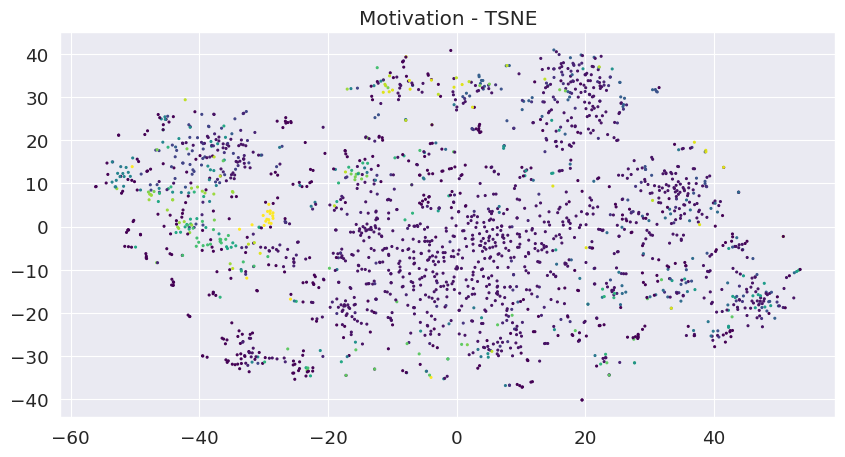

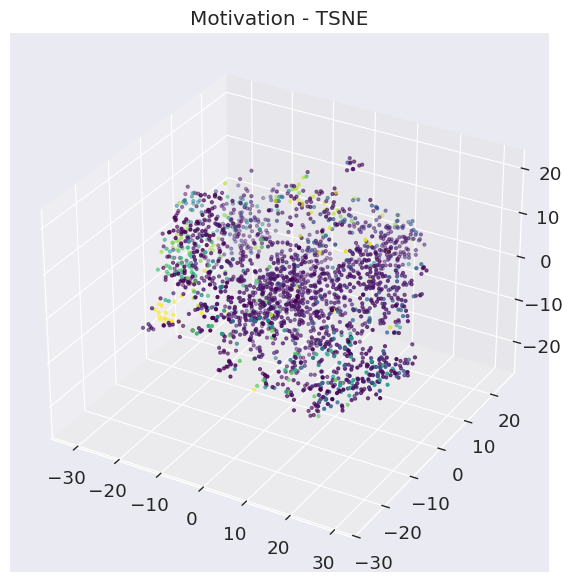

In [52]:
motivation_clustering.plot_clusters_2d(embs_2d, labels, "Motivation - TSNE")
motivation_clustering.plot_clusters_3d(embs_3d, labels, "Motivation - TSNE")

In [14]:
STOP = ['a', 'about', 'again', 'ain', 'am', 'an', 'and', 'are', 'aren', "aren't", 'at', 'be', 'because', 'been', 'being', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'during', 'each', 'for', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'i', 'in', 'into', 'is', 'isn', "isn't", 'it', "it's", 'its', 'itself', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'or', 'ourselves', 'out', 'own', 're', 's', 'shan', "shan't", 'she', "she's", 'should', "should've", 'shouldn', "shouldn't", 'so', 'such', 't', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 'then', 'there', 'these', 'they', 'this', 'those', 'through', 'to', 'too', 'until', 've', 'very', 'was', 'wasn', "wasn't", 'we', 'were', 'weren', "weren't", 'will', 'with', 'won', "won't", 'wouldn', "wouldn't", 'y', 'you', "you'd", "you'll", "you're", "you've", 'your', 'yours', 'yourself', 'yourselves']

motivation_stops = [" ".join(word for word in motivation.split() if word not in STOP) for motivation in motivations]
motivation_stops[:5]

['develop foundation multimodal language model, called S PI R IT -LM, generate both speech text cross-modal manner, combining generative abilities pretrained knowledge text language models expressive capacities speech-language models.',
 'improve efficiency autoregressive language models developing adaptive scalable tree structure called OPT-Tree speculative decoding, which accelerate decoding while maintaining original output distribution.',
 'develop efficient method optimizing tokenizers non-English languages without increasing vocabulary size, thereby enhancing token efficiency performance multilingual language models.',
 'address issue analyzing generating Indonesian words creating morphology engine, IndoMorph, handle complex morphology Indonesian language, low-resource language NLP field.',
 'improve accuracy lemmatization Estonian language integrating external disambiguation model rule-based morphological analyzer evaluate impact downstream information retrieval task.']

In [ ]:
model = BERTopic(embedding_model=_sentence_encoder())
motivation_topics, probs = model.fit_transform(motivation_stops)
print("Topics found (default):", len(set(motivation_topics)))

Topics found (default): 36


In [ ]:
# ag = AgglomerativeClustering(n_clusters=40)
# ap = AffinityPropagation()
# op = OPTICS(min_samples=10)
# km = KMeans(n_clusters=40)

# representation_model = MaximalMarginalRelevance(diversity=0.2)

# model = BERTopic(embedding_model=_sentence_encoder(), min_topic_size=10, calculate_probabilities=True, hdbscan_model=ag, representation_model=representation_model)
# motivation_topics, probs = model.fit_transform(motivation_stops)
# # motivation_topics = model.reduce_outliers(motivation_stops, motivation_topics, strategy="embeddings", embeddings=embs)
# # model.update_topics(motivation_stops, motivation_topics)
# model.save("data/motivation_bertopic_model.safetensors", "safetensors", save_embedding_model=True, save_ctfidf=True)

/lnet/work/people/vico/TokSurvey/.venv/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning:

The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.



In [21]:
model = BERTopic.load("data/motivation_bertopic_model.safetensors", embedding_model=_sentence_encoder())
motivation_topics, probs = model.transform(motivation_stops)
print("Topics found (custom):", len(set(motivation_topics)))

Topics found (custom): 40


In [22]:
model.get_topic_info()#["Count"].sum()

,Topic,Count,Name,Representation,Representative_Docs
0,0,113,0_tokenization_korean_subword_encoding,"[tokenization, korean, subword, encoding, lang...",NaN
1,1,110,1_morphological_segmentation_languages_morpheme,"[morphological, segmentation, languages, morph...",NaN
2,2,109,2_translation_neural_improve_quality,"[translation, neural, improve, quality, nmt, s...",NaN
3,3,100,3_pre_trained_domain_token,"[pre, trained, domain, token, improve, vocabul...",NaN
4,4,97,4_reasoning_privacy_knowledge_llms,"[reasoning, privacy, knowledge, llms, model, a...",NaN
5,5,96,5_multimodal_vision_mllms_language,"[multimodal, vision, mllms, language, modal, m...",NaN
6,6,79,6_chinese_word_segmentation_tagging,"[chinese, word, segmentation, tagging, part, m...",NaN
7,7,70,7_translation_languages_subword_segmentation,"[translation, languages, subword, segmentation...",NaN
8,8,67,8_memory_attention_computational_compression,"[memory, attention, computational, compression...",NaN
9,9,66,9_graph_molecular_rna_molecule,"[graph, molecular, rna, molecule, cell, genome...",NaN


In [30]:
model.get_topic_info()["Count"].sum()

np.int64(2090)

In [27]:
hierarchical_topics = model.hierarchical_topics(motivation_stops, use_ctfidf=True)

# Print topic tree
tree = model.get_topic_tree(hierarchical_topics, tight_layout=True)
print(tree.replace("_", ", "))

  0%|                                                                                                                                                                                               | 0/39 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:00<00:00, 310.97it/s]

.
├─models, large, language, develop, novel
│ ├─visual, image, vision, develop, multimodal
│ │ ├─graph, series, time, data, protein
│ │ │ ├─■──forecasting, data, brain, multivariate, eeg ── Topic: 16
│ │ │ └─graph, protein, molecular, motion, develop
│ │ │   ├─■──graph, molecular, rna, molecule, cell ── Topic: 9
│ │ │   └─■──motion, environments, action, autonomous, interactive ── Topic: 28
│ │ └─image, visual, vision, video, multimodal
│ │   ├─visual, vision, multimodal, video, image
│ │   │ ├─■──vision, token, transformer, spatial, efficient ── Topic: 23
│ │   │ └─visual, multimodal, video, vision, large
│ │   │   ├─■──video, visual, vision, vlms, inference ── Topic: 14
│ │   │   └─■──multimodal, vision, mllms, language, modal ── Topic: 5
│ │   └─■──diffusion, images, generative, video, modeling ── Topic: 22
│ └─models, large, language, token, novel
│   ├─attention, transformer, computational, memory, while
│   │ ├─■──pruning, token, prompts, attention, mask ── Topic: 35
│   │ └─atte

In [24]:
topic_labels = model.generate_topic_labels(nr_words=10, separator=", ")
topic_labels

['0, tokenization, korean, subword, encoding, languages, processing, byte, vocabulary, tokenizers, morphological',
 '1, morphological, segmentation, languages, morpheme, morphemes, morphology, polysynthetic, annotated, sequence, morphologically',
 '2, translation, neural, improve, quality, nmt, subword, multilingual, resource, byte, languages',
 '3, pre, trained, domain, token, improve, vocabulary, learning, pretraining, context, embeddings',
 '4, reasoning, privacy, knowledge, llms, model, ai, mathematical, text, token, editing',
 '5, multimodal, vision, mllms, language, modal, model, understanding, framework, representations, token',
 '6, chinese, word, segmentation, tagging, part, multi, knowledge, character, art, labeling',
 '7, translation, languages, subword, segmentation, morphologically, encoding, byte, lingual, augmentation, tokenization',
 '8, memory, attention, computational, compression, reducing, bert, sparse, packing, layers, transformer',
 '9, graph, molecular, rna, mole

In [25]:
model.visualize_hierarchy(hierarchical_topics=hierarchical_topics, use_ctfidf=True)

In [70]:
years = real_tokenization[~real_tokenization['exclude']]['year'].to_list()
topics_over_time = model.topics_over_time(motivations, years)
model.visualize_topics_over_time(topics_over_time, normalize_frequency=True, top_n_topics=10)

## Languages

In [16]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
import collections
import itertools
from pyglottolog import Glottolog, fts 
import dotenv
from thefuzz import fuzz, process
import language_data
dotenv.load_dotenv()
tqdm.tqdm.pandas()
# glottolog = Glottolog(os.getenv('GLOTTOLOG_REPOS'), cache=True)
glottolog = language_data.get_glottolog_instance()
_ = language_data.get_language_index()

In [17]:
# !glottolog --repos $GLOTTOLOG_REPOS searchindex

In [145]:
importlib.reload(llm_filter)
importlib.reload(language_data)

<module 'language_data' from '/lnet/work/people/vico/TokSurvey/language_data.py'>

In [18]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

(2152, 20)

In [19]:
# all_answers_languages = []
# for answer in llm_filter.get_units(real_tokenization):
#     all_answers_languages.append(answer)
    
# with open('data/raw_answers/language_answer.json', 'wt') as f:
#     json.dump(all_answers_languages, f, indent=2)

In [20]:
with open('data/raw_answers/language_answer.json') as f:
    all_answers_languages = json.load(f)
all_answers_languages[:5]

['English, French, Belgian, North American English',
 '* English \n* Chinese',
 '* Japanese\n* Chinese\n* English',
 '1. Indonesian\n2. Standard Malay\n3. Finnish\n4. Turkish\n5. Japanese\n6. Tagalog\n7. Javanese\n8. Balinese',
 '* Estonian\n* English\n* Basque\n* Russian\n* Spanish']

In [21]:
# search with glottolog: name (language), name (dialect), name (family)
# search_langs(glottolog, 'North American English', name="North American English", limit=1)
# Missing: check manually
# Traditional Chinese: use as mandarin

In [22]:
lang_sets = [llm_filter.extract_languages(i) for i in all_answers_languages]
all_langs = sorted(list(set(itertools.chain.from_iterable(lang_sets))))
print(len(all_langs), 'languages found before cleaning')

1067 languages found before cleaning


In [23]:
# Find languages that are not in glottolog. For cleanining
# GL = list(glottolog.languoids())
# GL_NAMES = [l.name for l in GL]

# glottolangs = []
# missing_langs = []
# for lang in tqdm.tqdm(all_langs):
#     n, l = fts.search_langs(glottolog, "", name=lang, limit=10)
#     if n == 0:
#         missing_langs.append(lang)
#     else:
#         glottolangs.append(l[0])

# matches = []
# for i in tqdm.tqdm(missing_langs):
#     n, l = fts.search_langs(glottolog, i, limit=5)
#     tmp_names = [ll.name for ll in l]
#     if len(tmp_names) == 0:        
#         matches.append((i, None))
#     else:
#         matches.append((i, process.extractBests(i, tmp_names)))

# for i in matches:
#     print(i)

In [24]:
glottolang_sets = []
for lang_set in tqdm.tqdm(lang_sets):
    lset = set()
    for lang in lang_set:                    
        languoid = language_data.map_to_glottolog(lang)
        lset.add(languoid)
    glottolang_sets.append(lset)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2153/2153 [00:00<00:00, 71134.70it/s]


In [25]:
macroareas = collections.Counter()
russian_languages = 0
macroareas_sets = []
rep = {"Eurasia": "Asia"}
for glottolang_set, exclude in tqdm.tqdm(zip(glottolang_sets, real_tokenization["exclude"].to_list())):
    if exclude:
        continue
    areas = set()
    russia = False
    for lang in glottolang_set:
        if language_data.is_european(lang):
            areas.add("Europe")
        elif language_data.is_exclusive_russian(lang):
            areas.add("Europe")
            russia = True
        else:
            areas.update(language_data.get_macroarea(lang, rep))
    if russia:
        russian_languages += 1
    if len(areas) == 0:
        areas = {"None",}
    macroareas.update(areas)
    macroareas_sets.append(tuple(sorted(list(areas))))
for i in macroareas.most_common():
    print(i)
print("russia:", russian_languages)
for i in collections.Counter(macroareas_sets).most_common():
    print(i)

2152it [00:00, 2394.66it/s]

('Europe', 1964)
('Asia', 845)
('None', 572)
('Africa', 150)
('North America', 63)
('Papunesia', 51)
('South America', 17)
('Australia', 3)
russia: 38
(('Europe',), 952)
(('Asia', 'Europe'), 501)
(('Asia', 'Europe', 'None'), 176)
(('Europe', 'None'), 143)
(('None',), 92)
(('Africa', 'Asia', 'Europe', 'None'), 54)
(('Africa', 'Asia', 'Europe', 'None', 'Papunesia'), 15)
(('Asia',), 15)
(('Africa', 'Europe', 'None'), 14)
(('Africa', 'Europe'), 14)
(('Africa', 'Asia', 'Europe'), 13)
(('Asia', 'Europe', 'None', 'North America'), 11)
(('Asia', 'Europe', 'None', 'Papunesia'), 8)
(('Europe', 'None', 'North America'), 8)
(('Africa', 'Asia', 'Europe', 'None', 'North America', 'Papunesia', 'South America'), 8)
(('Africa', 'Asia', 'Europe', 'None', 'North America', 'Papunesia'), 8)
(('Asia', 'None'), 7)
(('Europe', 'North America'), 6)
(('Africa', 'Asia', 'None'), 6)
(('Asia', 'Europe', 'North America'), 6)
(('Europe', 'Papunesia'), 4)
(('Africa', 'Asia', 'Europe', 'None', 'North America'), 4)
(('

None: 572
Europe: 1964
Asia: 845
Africa: 150
North America: 63
Papunesia: 51
South America: 17
Australia: 3


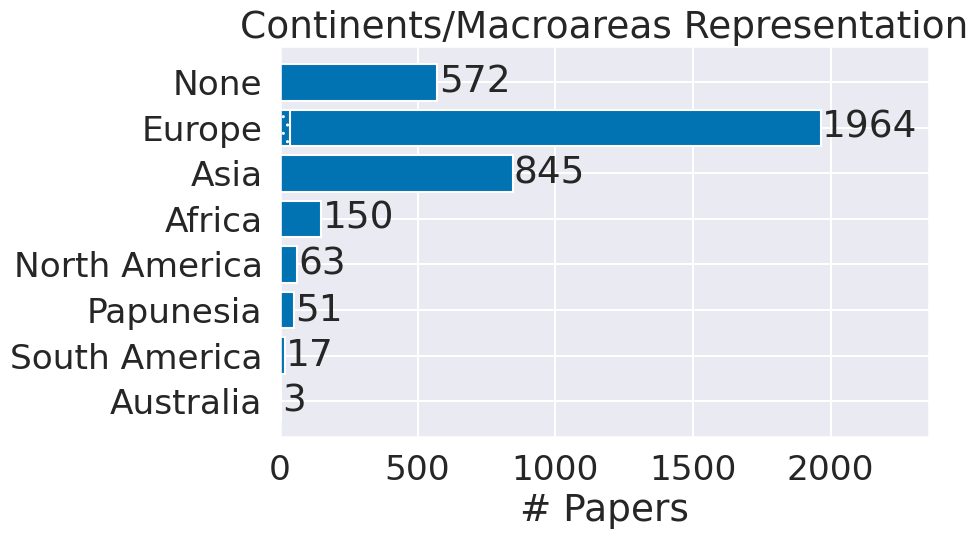

In [ ]:
# Plot macroarea counts, overlap bars with Europe (filled) and Russia (hatched)
areas = [ "None", "Europe", "Asia", "Africa", "North America", "Papunesia", "South America", "Australia"]
counts = [macroareas[area] for area in areas]
for i, area in enumerate(areas):
    print(f"{area}: {counts[i]}")
plt.figure(figsize=(10, 6))
plt.barh(areas, counts)
plt.barh(["Europe"], [russian_languages], color='C0', hatch='..', label='Russia')

plt.gca().invert_yaxis()
plt.title('Macroareas Representation')
plt.xlabel('# Papers')
# Add the frequency values to the bars
for i, v in enumerate(counts):
    plt.text(v + 5, i, str(v), va='center')
plt.xlim(0, max(counts)*1.2)
# plt.legend()
plt.tight_layout()
plt.savefig("plots/language_macroareas.pdf", bbox_inches='tight')
plt.show()

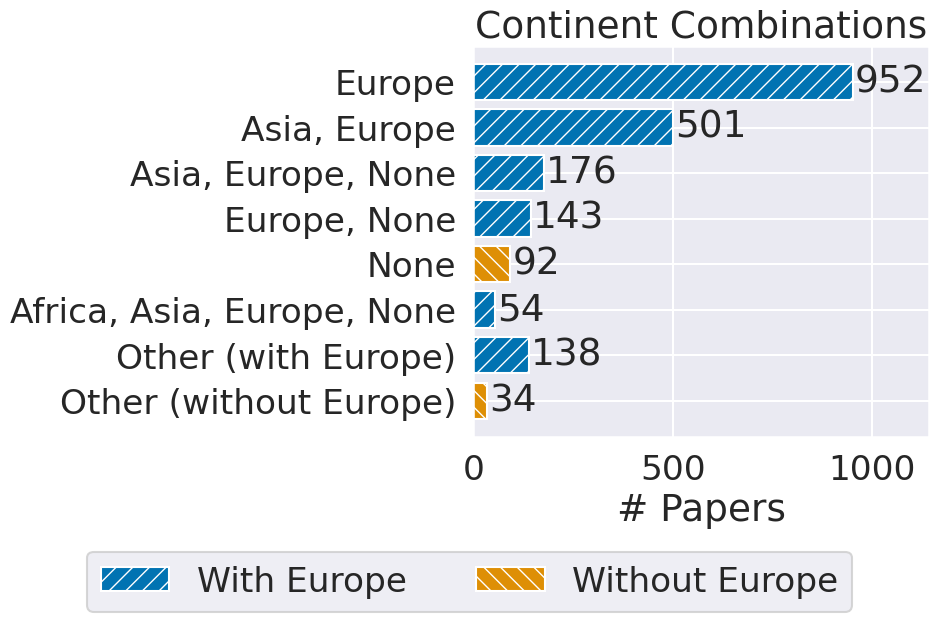

In [186]:
# Plot collections.Counter(macroareas_sets).most_common()
from matplotlib.patches import Rectangle
plt.figure(figsize=(10, 6))
macroarea_set_counts = collections.Counter(macroareas_sets).most_common()
labels, counts = zip(*macroarea_set_counts[:20])
labels = [", ".join(label) for label in labels]
n = 6
labels_plot = list(labels[:n])
counts_plot = list(counts[:n])
labels_others = ["Other (with Europe)", "Other (without Europe)"]
count_others_with_europe = sum(c for l, c in macroarea_set_counts[n:] if "Europe" in l)
count_others_without_europe = sum(c for l, c in macroarea_set_counts[n:] if "Europe" not in l)
labels_plot += labels_others
counts_plot += [count_others_with_europe, count_others_without_europe]
plt.barh(labels_plot, counts_plot, color=['C0' if 'Europe' in label and 'without' not in label else 'C1' for label in labels_plot], hatch=['//' if 'Europe' in label and 'without' not in label else '\\\\' for label in labels_plot])
plt.gca().invert_yaxis()
plt.title('Continent Combinations')
plt.xlabel('# Papers')
# Add a legend for Europe color
plt.gca().figure.legend(handles=[Rectangle((0,0),1,1, facecolor='C0', hatch='//'), Rectangle((0,0),1,1, facecolor='C1', hatch='\\\\')], labels=['With Europe', 'Without Europe'], loc='outside lower center', ncols=2, bbox_to_anchor=(0.5, -0.1))
# Add the frequency values to the bars
for i, v in enumerate(counts_plot):
    plt.text(v + 5, i, str(v), va='center')
plt.xlim(0, max(counts_plot)*1.2)
plt.tight_layout()
plt.savefig("plots/language_macroarea_combinations.pdf", bbox_inches='tight')
plt.show()

In [182]:
family_counts = collections.Counter()
for glottolang_set, exclude in tqdm.tqdm(zip(glottolang_sets, real_tokenization["exclude"].to_list())):
    if exclude:
        continue
    families = set()
    for lang in glottolang_set:
        family = language_data.get_family(lang)
        if family is None:
            if lang.category == 'Family':
                family = lang.name
            else:                
                family = "None"
        families.add(family)
    for family in families:
        family_counts[family] += 1
for i in family_counts.most_common(20):
    print(i)

2152it [00:00, 3116.11it/s]

('Indo-European', 1967)
('Sino-Tibetan', 537)
('None', 400)
('Afro-Asiatic', 267)
('Japonic', 254)
('Turkic', 211)
('Uralic', 188)
('Koreanic', 146)
('Atlantic-Congo', 111)
('Austroasiatic', 107)
('Dravidian', 89)
('Tai-Kadai', 75)
('Austronesian', 48)
('Mongolic-Khitan', 47)
('Kartvelian', 35)
('Uto-Aztecan', 21)
('Algic', 17)
('Arawakan', 14)
('Artificial Language', 13)
('Eskimo-Aleut', 11)


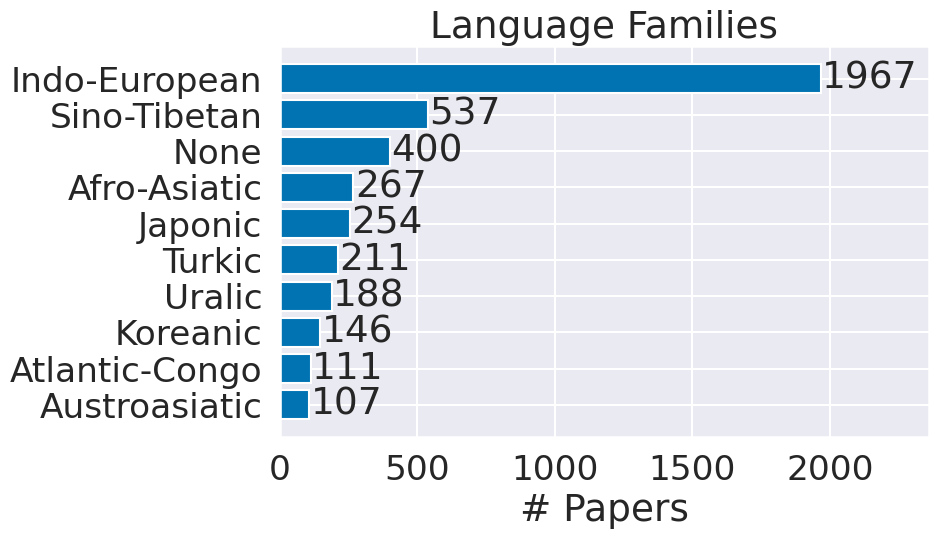

In [184]:
# Plot family counts
most_common_families = family_counts.most_common(10)
families, counts = zip(*most_common_families)
plt.figure(figsize=(10, 6))
plt.barh(families, counts)
plt.gca().invert_yaxis()
plt.title('Language Families')
plt.xlabel('# Papers')
# Add the frequency values to the bars
for i, v in enumerate(counts):
    plt.text(v + 5, i, str(v), va='center')
plt.xlim(0, max(counts)*1.2)
plt.tight_layout()
plt.savefig("plots/language_families.pdf", bbox_inches='tight')
plt.show()

In [188]:
unique_languages = list(set(itertools.chain.from_iterable(glottolang_sets)))
len(unique_languages)

694

In [189]:
freq = collections.Counter()
for langs in glottolang_sets:
    freq.update([i.name if i else 'None' for i in langs])
freq.most_common(20)

[('English', 1927),
 ('Chinese', 501),
 ('German', 428),
 ('None', 390),
 ('French', 336),
 ('Spanish', 272),
 ('Japanese', 254),
 ('Arabic', 234),
 ('Russian', 199),
 ('Turkish', 192),
 ('Italian', 165),
 ('Hindi', 158),
 ('Finnish', 145),
 ('Korean', 144),
 ('Czech', 128),
 ('Dutch', 114),
 ('Portuguese', 114),
 ('Vietnamese', 101),
 ('Romanian', 95),
 ('Hungarian', 83)]

In [190]:
freq.most_common()[-10:]

[('Cashinahua', 1),
 ('Jehai', 1),
 ('Ho-Chunk', 1),
 ('Movima', 1),
 ('Orkon-Fanbak', 1),
 ('Nisvai', 1),
 ('Ponapean', 1),
 ('Gubeeher-Gufangor-Gubelor', 1),
 ('Ngalkbun', 1),
 ('Goemai', 1)]

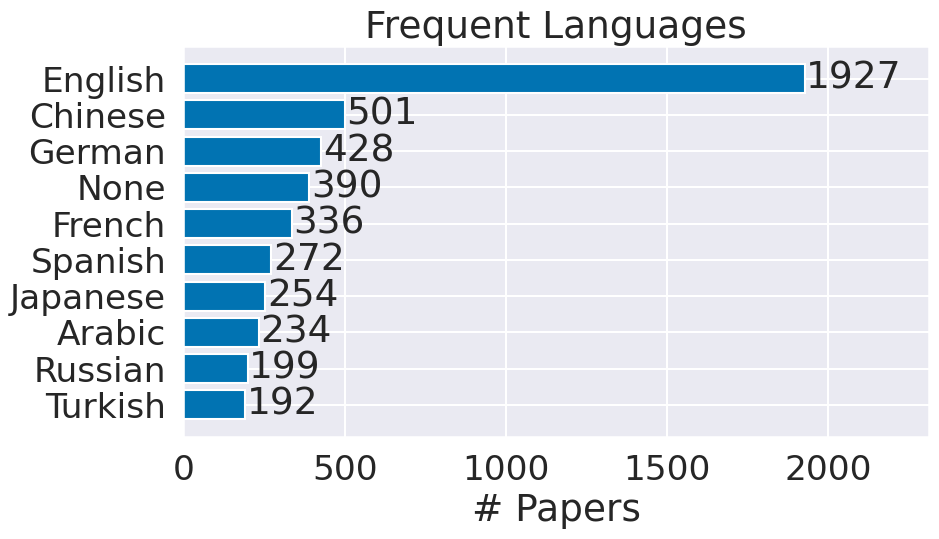

In [192]:
# Plot the most common languages
most_common = freq.most_common(10)
languages, counts = zip(*most_common)
plt.figure(figsize=(10, 6))
plt.barh(languages, counts)
# plt.xticks(rotation=90)
plt.xlabel('# Papers')
plt.gca().invert_yaxis()
plt.title('Frequent Languages')
# Add the frequency values to the bars
for i, v in enumerate(counts):
    plt.text(v + 5, i, str(v), va='center')
plt.xlim(0, max(counts)*1.2)
plt.tight_layout()
plt.savefig("plots/common_languages.pdf", bbox_inches='tight')
plt.show()  


In [25]:
collections.Counter(real_tokenization.type.to_list())

Counter({'acl': 1511, 'icml': 230, 'iclr': 210, 'neurips': 190, 'colm': 11})

Max number of languages in a paper: 155
Average number of languages in a paper: 4.566507177033492
Median number of languages in a paper: 2
Number of papers with only 1 language: 737
Number of papers with no languages: 78
90th percentile of number of languages in a paper: 9


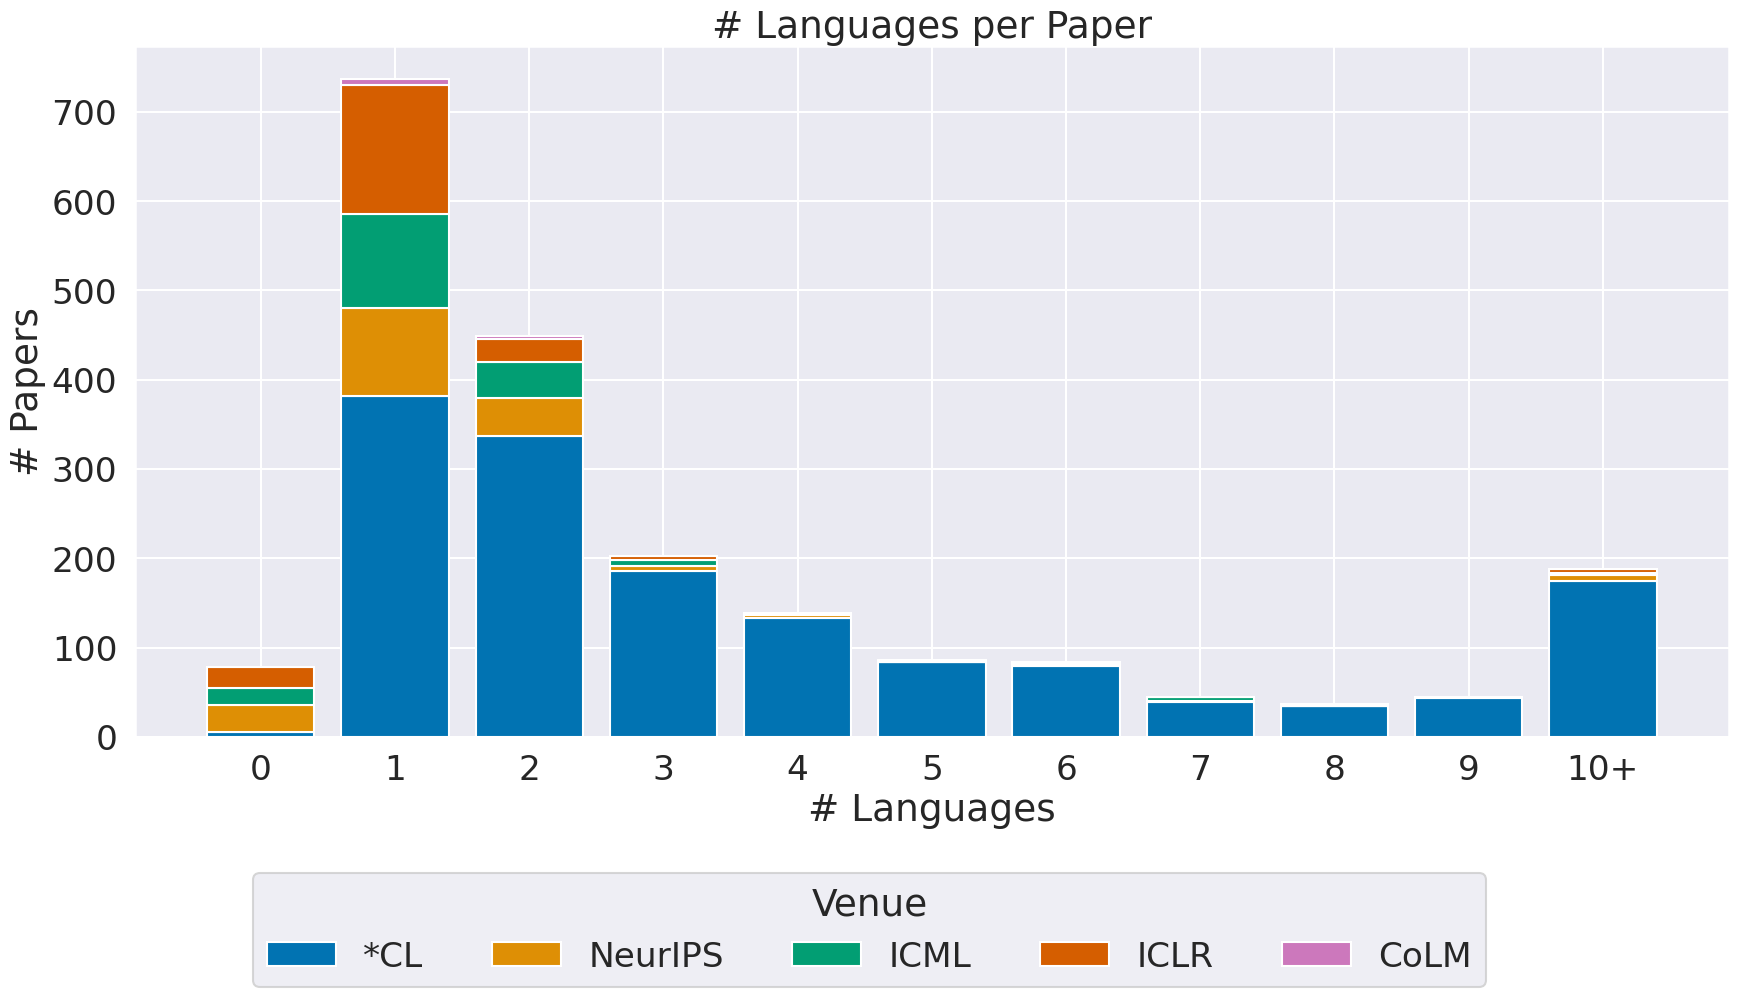

In [31]:
# Plot number of unique languages per paper, stack based on type of paper
# Add 10+ columns
n_langs = [len(langs) for langs, exclude in zip(glottolang_sets, real_tokenization["exclude"].to_list()) if not exclude]
print("Max number of languages in a paper:", max(n_langs))
print("Average number of languages in a paper:", sum(n_langs) / len(n_langs))
print("Median number of languages in a paper:", sorted(n_langs)[len(n_langs)//2])
print("Number of papers with only 1 language:", sum(1 for n in n_langs if n == 1))
print("Number of papers with no languages:", sum(1 for n in n_langs if n == 0))
print("90th percentile of number of languages in a paper:", sorted(n_langs)[int(len(n_langs) * 0.9)])

venue_map = {
    "acl": "*CL",
    "neurips": "NeurIPS",
    "icml": "ICML",
    "iclr": "ICLR",
    "colm": "CoLM",
}
# Plot number of unique languages per paper, stacked based on type of paper
n_langs_by_type = {}
for paper_type in real_tokenization['type'].unique():
    n_langs_by_type[paper_type] = [
        len(langs) for langs, exclude, paper_type_filter in zip(
            glottolang_sets, real_tokenization["exclude"].to_list(), real_tokenization["type"].to_list()
        ) if not exclude and paper_type_filter == paper_type
    ]

plt.figure(figsize=(18, 9))
n = 10
bins = range(0, n + 2)
# for paper_type, counts in n_langs_by_type.items():
#     plt.hist(counts, bins=bins, align='left', rwidth=0.8, label=venue_map.get(paper_type, paper_type), alpha=1, stacked=True)    
counts = {}

for paper_type, langs in n_langs_by_type.items():
    counts[paper_type] = [i if i < n else n for i in langs]
plt.hist(counts.values(), bins=bins, align='left', rwidth=0.8, label=[venue_map.get(paper_type, paper_type) for paper_type in n_langs_by_type.keys()], alpha=1, stacked=True)    

plt.xticks(range(0,n+1), [str(i) for i in range(0, n)] + [f"{n}+"] )
plt.xlabel('# Languages')
plt.ylabel('# Papers')
plt.title('# Languages per Paper')
# plt.legend(title='Venue')
# plt.gca().figure.legend(loc="outside right center", ncols=1, bbox_to_anchor=(1.25, 0.6), title='Venue')
plt.gca().figure.legend(loc="outside lower center", ncols=5, bbox_to_anchor=(0.5, -0.15), title='Venue')
plt.tight_layout()
plt.savefig("plots/languages_per_paper.pdf", bbox_inches='tight')
plt.show()

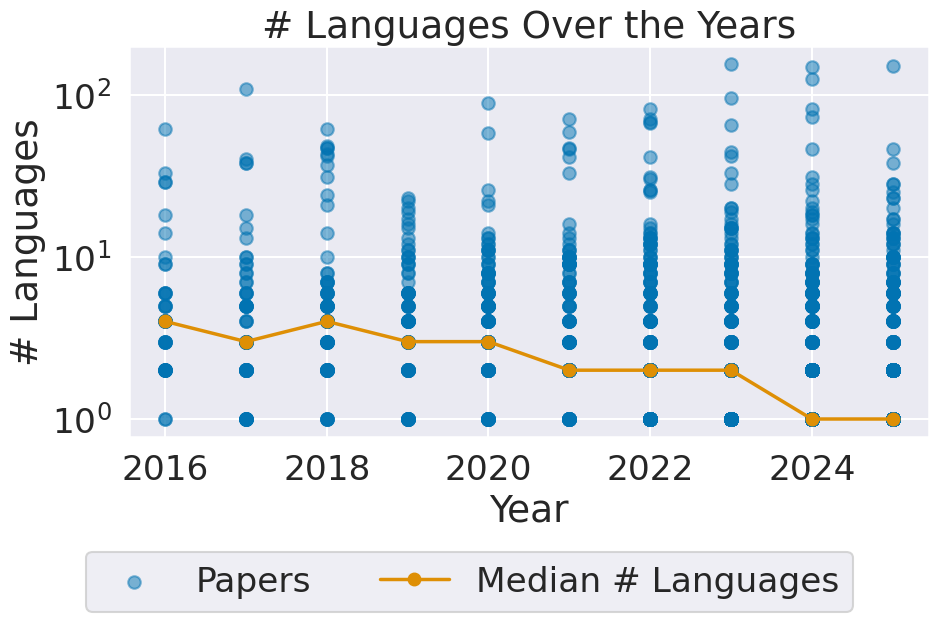

In [71]:
# Number of languages over the years, scatter plot and line plot of median number of languages
years = real_tokenization[~real_tokenization['exclude']]['year'].to_list()
n_langs = [len(langs) for langs, exclude in zip(glottolang_sets, real_tokenization["exclude"].to_list()) if not exclude]
plt.figure(figsize=(10, 6))
plt.scatter(years, n_langs, alpha=0.5, label='Papers')
# Line plot of median number of languages per year
year_langs = {}
for year, langs in zip(years, n_langs):
    if year not in year_langs:
        year_langs[year] = []
    year_langs[year].append(langs)
year_median_langs = {year: sorted(langs)[len(langs) // 2] for year, langs in year_langs.items()}
year_mean_langs = {year: sum(langs) / len(langs) for year, langs in year_langs.items()}
year_max_langs = {year: max(langs) for year, langs in year_langs.items()}
year_mode_langs = {year: collections.Counter(langs).most_common(1)[0][0] for year, langs in year_langs.items()}
plt.plot(list(year_median_langs.keys()), list(year_median_langs.values()), color='C1', label='Median # Languages', marker='o')
# plt.plot(list(year_mean_langs.keys()), list(year_mean_langs.values()), color='C2', label='Mean # Languages', marker='s')
# plt.plot(list(year_max_langs.keys()), list(year_max_langs.values()), color='C3', label='Max # Languages', marker='^')
# plt.plot(list(year_mode_langs.keys()), list(year_mode_langs.values()), color='C4', label='Mode # Languages', marker='x')
plt.xlabel('Year')
plt.ylabel('# Languages')
plt.yscale('log')
plt.title('# Languages Over the Years')
plt.gca().figure.legend(loc="outside lower center", ncols=3, bbox_to_anchor=(0.5, -0.1))
plt.tight_layout()
plt.savefig("plots/languages_over_time.pdf", bbox_inches='tight')
plt.show()